# Bengluru House Price Prediction 

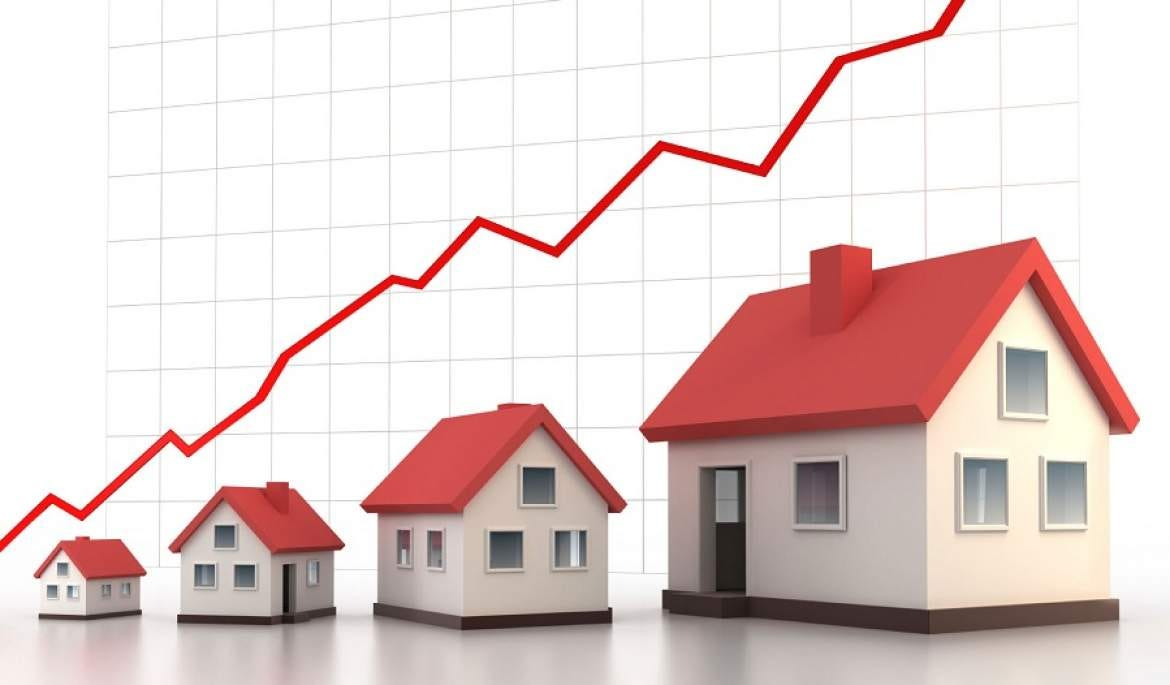

This is a code on House Price Prediction.

In [548]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

In [549]:
import warnings
warnings.filterwarnings('ignore')

In [550]:
df = pd.read_csv("bengaluru_house_data.csv")

In [551]:
df.head()

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00


In [552]:
df.tail()

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
13315,Built-up Area,Ready To Move,Whitefield,5 Bedroom,ArsiaEx,3453,4.0,0.0,231.0
13316,Super built-up Area,Ready To Move,Richards Town,4 BHK,NaN,3600,5.0,NaN,400.0
13317,Built-up Area,Ready To Move,Raja Rajeshwari Nagar,2 BHK,Mahla T,1141,2.0,1.0,60.0
13318,Super built-up Area,18-Jun,Padmanabhanagar,4 BHK,SollyCl,4689,4.0,1.0,488.0
13319,Super built-up Area,Ready To Move,Doddathoguru,1 BHK,NaN,550,1.0,1.0,17.0


In [553]:
df.shape

(13320, 9)

In [554]:
df.columns

Index(['area_type', 'availability', 'location', 'size', 'society',
       'total_sqft', 'bath', 'balcony', 'price'],
      dtype='object')

In [555]:
df.duplicated().sum()

529

In [556]:
df = df.drop_duplicates()

In [557]:
df.shape

(12791, 9)

In [558]:
df.isnull().sum()

area_type          0
availability       0
location           1
size              16
society         5328
total_sqft         0
bath              73
balcony          605
price              0
dtype: int64

In [559]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 12791 entries, 0 to 13318
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   area_type     12791 non-null  object 
 1   availability  12791 non-null  object 
 2   location      12790 non-null  object 
 3   size          12775 non-null  object 
 4   society       7463 non-null   object 
 5   total_sqft    12791 non-null  object 
 6   bath          12718 non-null  float64
 7   balcony       12186 non-null  float64
 8   price         12791 non-null  float64
dtypes: float64(3), object(6)
memory usage: 999.3+ KB


In [560]:
df.describe()

,bath,balcony,price
count,12718.000000,12186.000000,12791.000000
mean,2.708602,1.582308,114.317646
std,1.357764,0.822536,151.480310
min,1.000000,0.000000,8.000000
25%,2.000000,1.000000,50.000000
50%,2.000000,2.000000,73.000000
75%,3.000000,2.000000,121.000000
max,40.000000,3.000000,3600.000000


In [561]:
df.nunique()

area_type          4
availability      81
location        1305
size              31
society         2688
total_sqft      2117
bath              19
balcony            4
price           1994
dtype: int64

In [562]:
df['location'] = df['location'].fillna(df['location'].mode()[0])

In [563]:
df['society'] = df['society'].fillna('Unknown')

In [564]:
df['bath'] = df['bath'].fillna(df['bath'].mode()[0])

In [565]:
df['balcony'] = df['balcony'].fillna(df['balcony'].mode()[0])

In [566]:
df['total_sqrt_numerical']= df['size'].str.split().str[0]
df['total_sqrt_numerical'] = pd.to_numeric(df['total_sqrt_numerical'],errors ='coerce')

In [567]:
df = df.drop('size', axis = 1)

In [568]:
df['total_sqrt_numerical'] = df['total_sqrt_numerical'].fillna(df['total_sqrt_numerical'].mode()[0])

In [569]:
def calculate_mean(x):
    try:
        if '-' in x:
            values = x.split('-')
            if len(values) == 2:
                mean = (float(values[0]) +  float(values[1]))/2
            return mean
        else:
            return float(x)
    except ValueError:
        return np.nan
df['total_sqft'] = df['total_sqft'].apply(calculate_mean)

In [570]:
df = df.dropna()

In [571]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 12745 entries, 0 to 13318
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   area_type             12745 non-null  object 
 1   availability          12745 non-null  object 
 2   location              12745 non-null  object 
 3   society               12745 non-null  object 
 4   total_sqft            12745 non-null  float64
 5   bath                  12745 non-null  float64
 6   balcony               12745 non-null  float64
 7   price                 12745 non-null  float64
 8   total_sqrt_numerical  12745 non-null  float64
dtypes: float64(5), object(4)
memory usage: 995.7+ KB


In [572]:
df.describe()

,total_sqft,bath,balcony,price,total_sqrt_numerical
count,12745.00000,12745.000000,12745.000000,12745.000000,12745.000000
mean,1569.60368,2.703099,1.603295,114.207350,2.815771
std,1259.83493,1.352340,0.807231,151.591687,1.308425
min,1.00000,1.000000,0.000000,8.000000,1.000000
25%,1100.00000,2.000000,1.000000,50.000000,2.000000
50%,1280.00000,2.000000,2.000000,73.000000,3.000000
75%,1691.00000,3.000000,2.000000,120.000000,3.000000
max,52272.00000,40.000000,3.000000,3600.000000,43.000000


In [573]:
object_columns = df.select_dtypes(include=['object']).columns
print("Object type columns:")
print(object_columns)

numerical_columns = df.select_dtypes(include=['int64', 'float64']).columns
print("\nNumerical type columns:")
print(numerical_columns)

Object type columns:
Index(['area_type', 'availability', 'location', 'society'], dtype='object')

Numerical type columns:
Index(['total_sqft', 'bath', 'balcony', 'price', 'total_sqrt_numerical'], dtype='object')


In [574]:
def classify_features(df):
    categorical_features = []
    non_categorical_features = []
    discrete_features = []
    continuous_features = []

    for column in df.columns:
        if df[column].dtype == 'object':
            if df[column].nunique() < 10:
                categorical_features.append(column)
            else:
                non_categorical_features.append(column)
        elif df[column].dtype in ['int64', 'float64']:
            if df[column].nunique() < 15:
                discrete_features.append(column)
            else:
                continuous_features.append(column)

    return categorical_features, non_categorical_features, discrete_features, continuous_features

In [575]:
categorical, non_categorical, discrete, continuous = classify_features(df)

In [576]:
print("Categorical Features:", categorical)
print("Non-Categorical Features:", non_categorical)
print("Discrete Features:", discrete)
print("Continuous Features:", continuous)

Categorical Features: ['area_type']
Non-Categorical Features: ['availability', 'location', 'society']
Discrete Features: ['balcony']
Continuous Features: ['total_sqft', 'bath', 'price', 'total_sqrt_numerical']


In [577]:
df.isnull().sum()

area_type               0
availability            0
location                0
society                 0
total_sqft              0
bath                    0
balcony                 0
price                   0
total_sqrt_numerical    0
dtype: int64

In [578]:
for i in discrete:
    print(i)
    print(df[i].unique())
    print()

balcony
[1. 3. 2. 0.]



In [579]:
for i in discrete:
    print(df[i].value_counts())
    print()

balcony
2.0    5435
1.0    4683
3.0    1627
0.0    1000
Name: count, dtype: int64



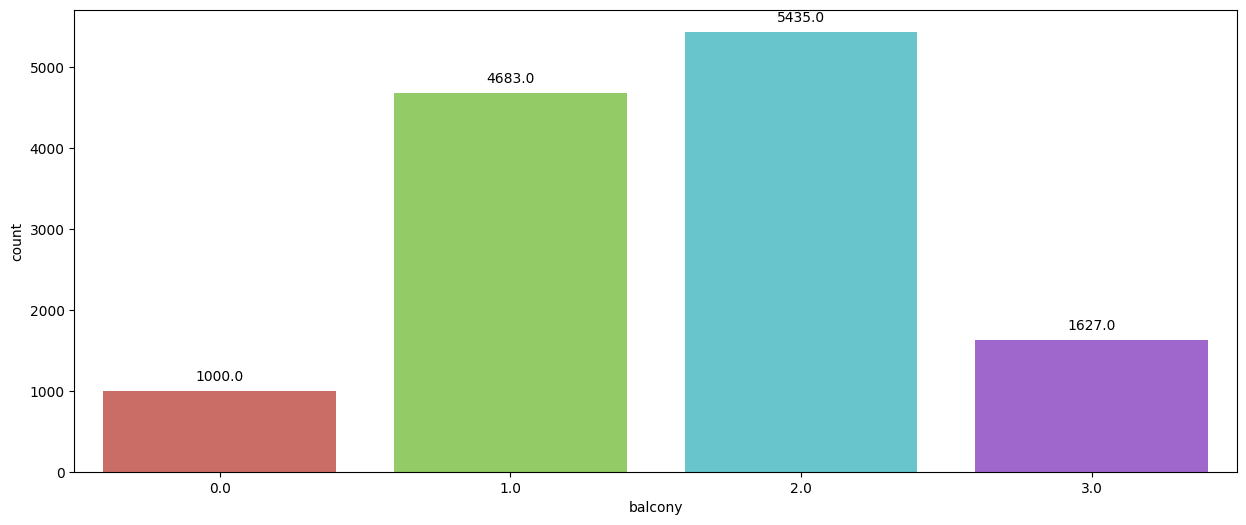

In [580]:
for i in discrete:
    plt.figure(figsize=(15, 6))
    ax = sns.countplot(x=i, data=df, palette='hls')

    for p in ax.patches:
        height = p.get_height()
        ax.annotate(f'{height}', 
                    xy=(p.get_x() + p.get_width() / 2., height),
                    xytext=(0, 10),  
                    textcoords='offset points',  
                    ha='center', va='center')  
    
    plt.show()

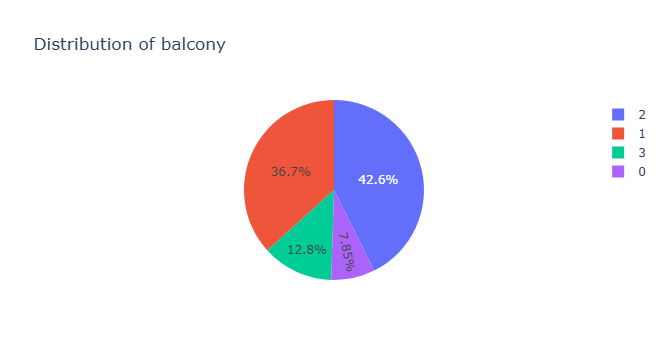

In [581]:
import plotly.express as px

for i in discrete:
    counts = df[i].value_counts()
    fig = px.pie(counts, values=counts.values, names=counts.index, title=f'Distribution of {i}')
    fig.show()

In [582]:
for i in categorical:
    print(i)
    print(df[i].unique())
    print()

area_type
['Super built-up  Area' 'Plot  Area' 'Built-up  Area' 'Carpet  Area']



In [583]:
for i in categorical:
    print(i)
    print(df[i].value_counts())
    print()

area_type
area_type
Super built-up  Area    8306
Built-up  Area          2382
Plot  Area              1971
Carpet  Area              86
Name: count, dtype: int64



In [584]:
df['area_type'].unique()

array(['Super built-up  Area', 'Plot  Area', 'Built-up  Area',
       'Carpet  Area'], dtype=object)

In [585]:
df['area_type'].value_counts()

area_type
Super built-up  Area    8306
Built-up  Area          2382
Plot  Area              1971
Carpet  Area              86
Name: count, dtype: int64

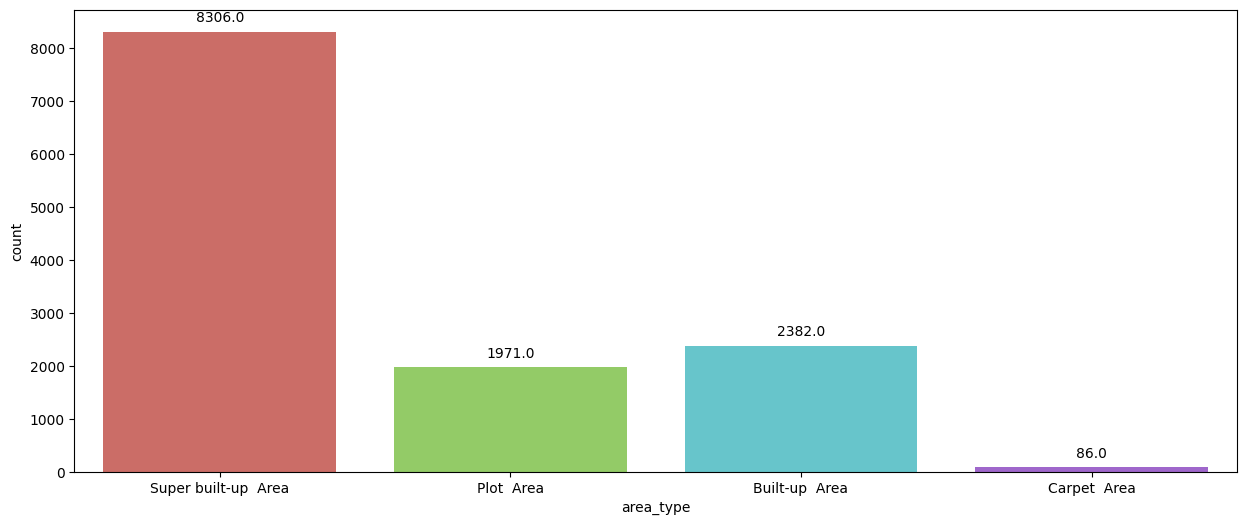

In [586]:
for i in categorical:
    plt.figure(figsize=(15, 6))
    ax = sns.countplot(x=i, data=df, palette='hls')

    for p in ax.patches:
        height = p.get_height()
        ax.annotate(f'{height}', 
                    xy=(p.get_x() + p.get_width() / 2., height),
                    xytext=(0, 10),  
                    textcoords='offset points',  
                    ha='center', va='center')  
    
    plt.show()

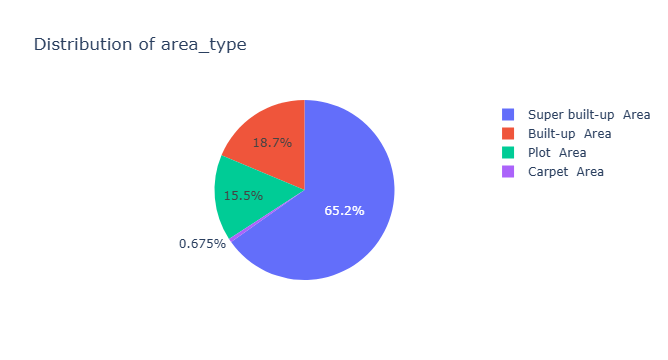

In [587]:
for i in categorical:
    counts = df[i].value_counts()
    fig = px.pie(counts, values=counts.values, names=counts.index, title=f'Distribution of {i}')
    fig.show()

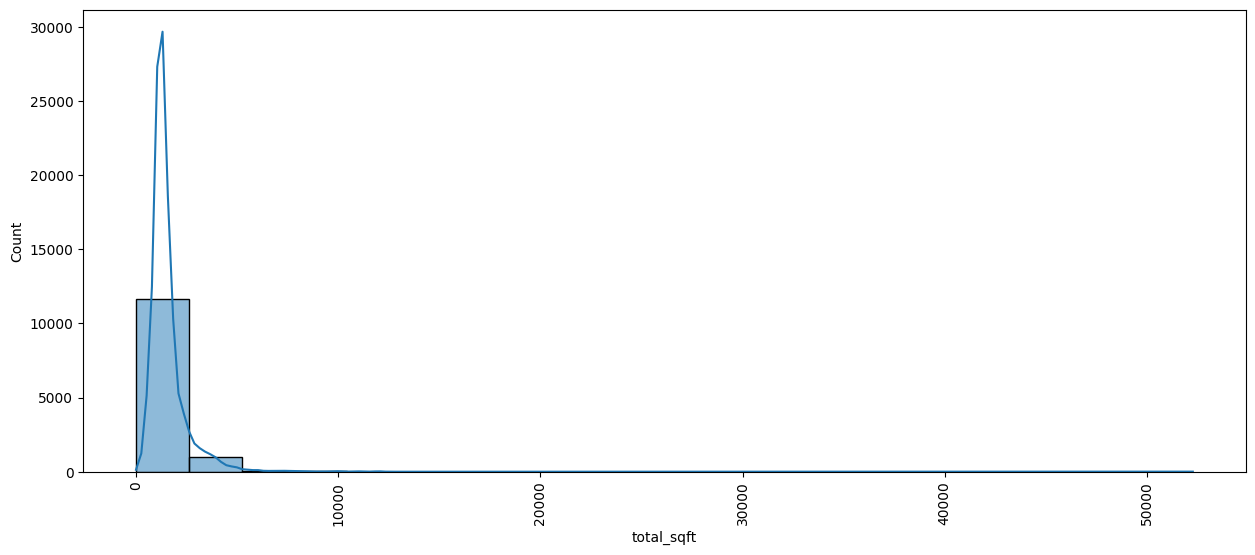

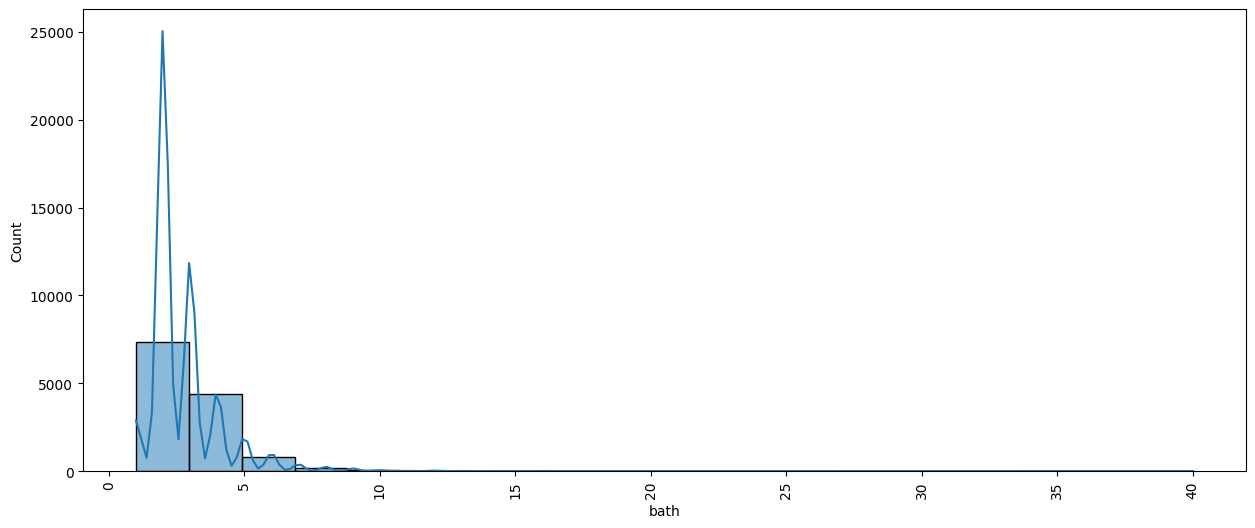

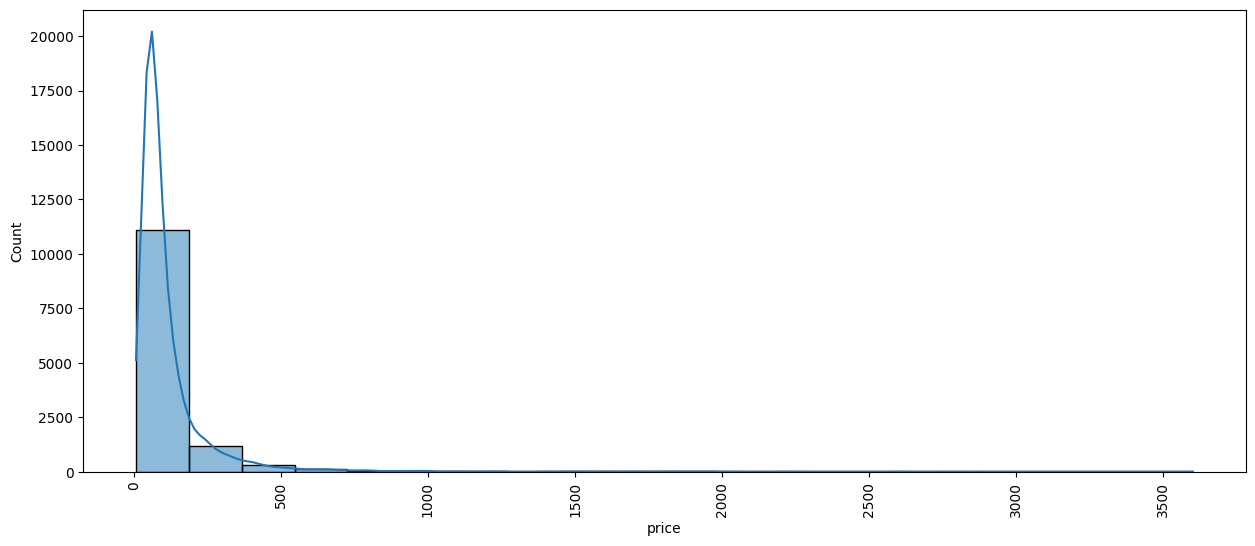

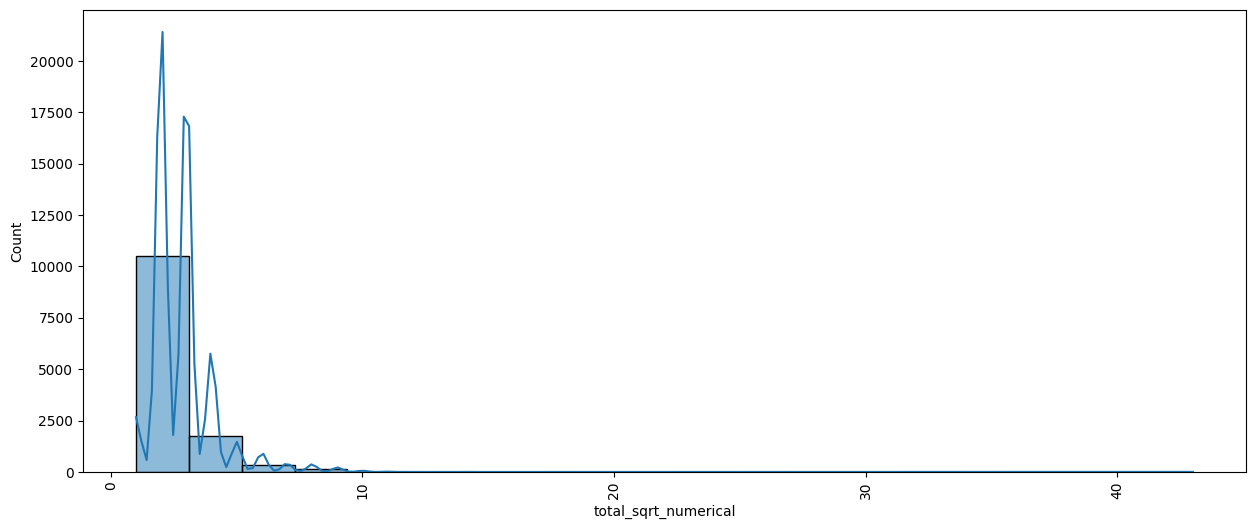

In [588]:
for i in continuous:
    plt.figure(figsize=(15,6))
    sns.histplot(df[i], bins = 20, kde = True, palette='hls')
    plt.xticks(rotation = 90)
    plt.show()

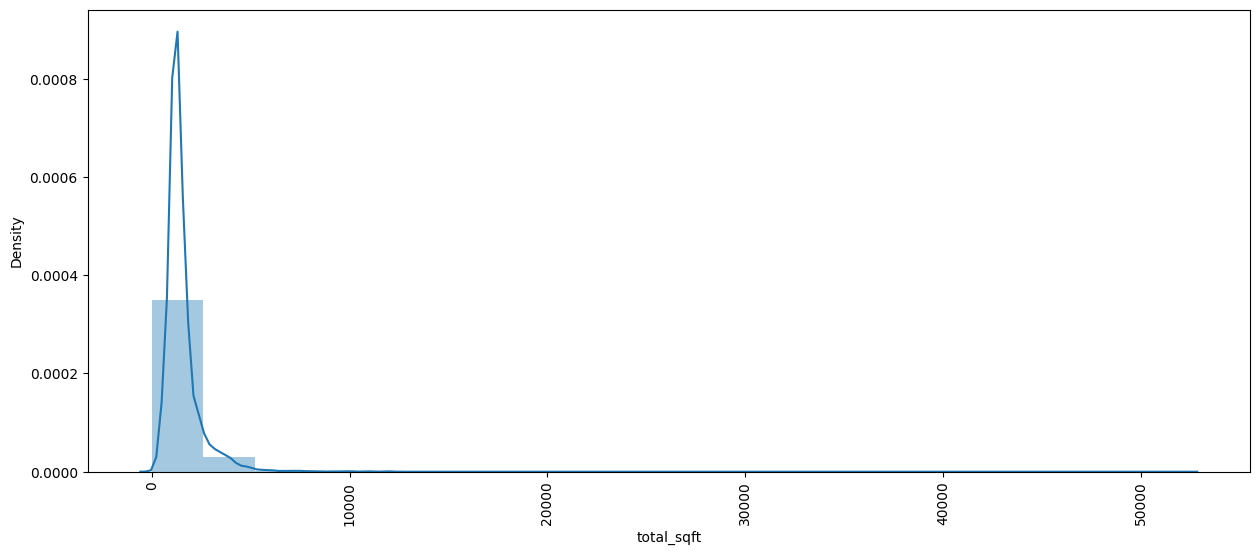

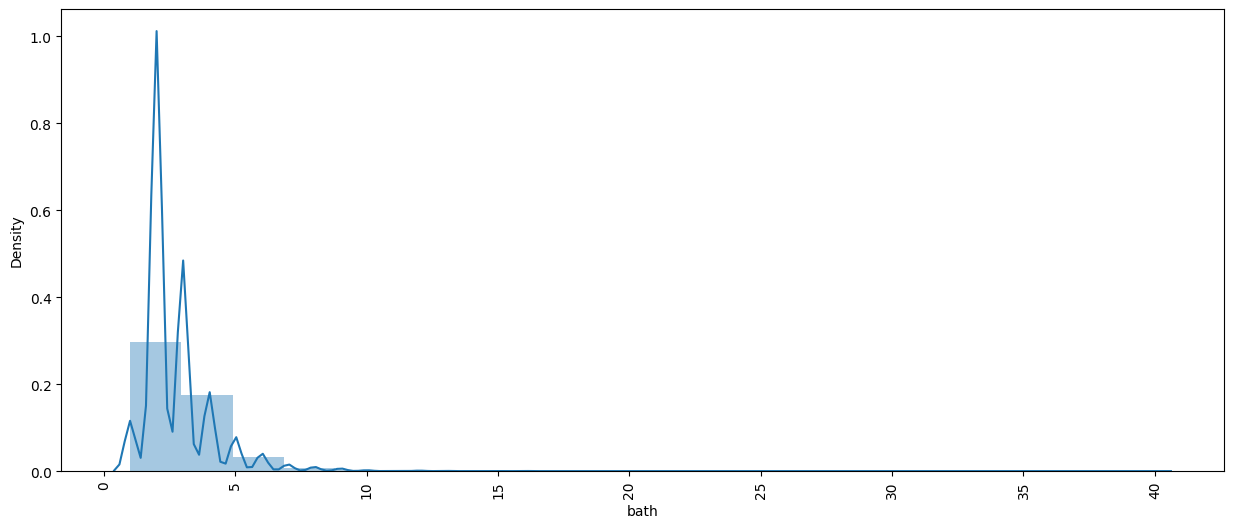

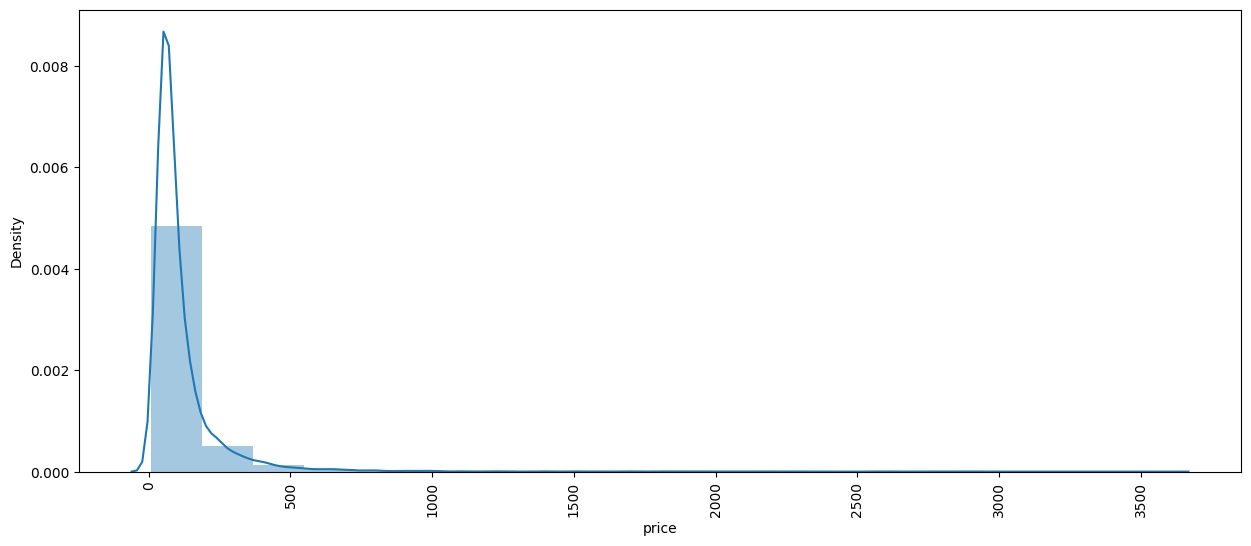

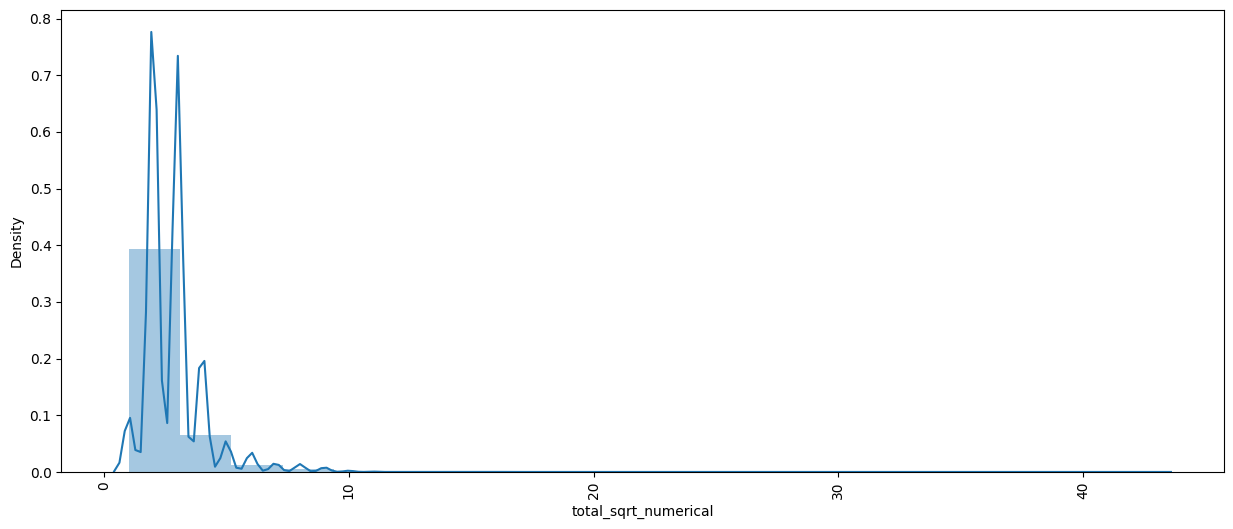

In [589]:
for i in continuous:
    plt.figure(figsize=(15,6))
    sns.distplot(df[i], bins = 20, kde = True)
    plt.xticks(rotation = 90)
    plt.show()

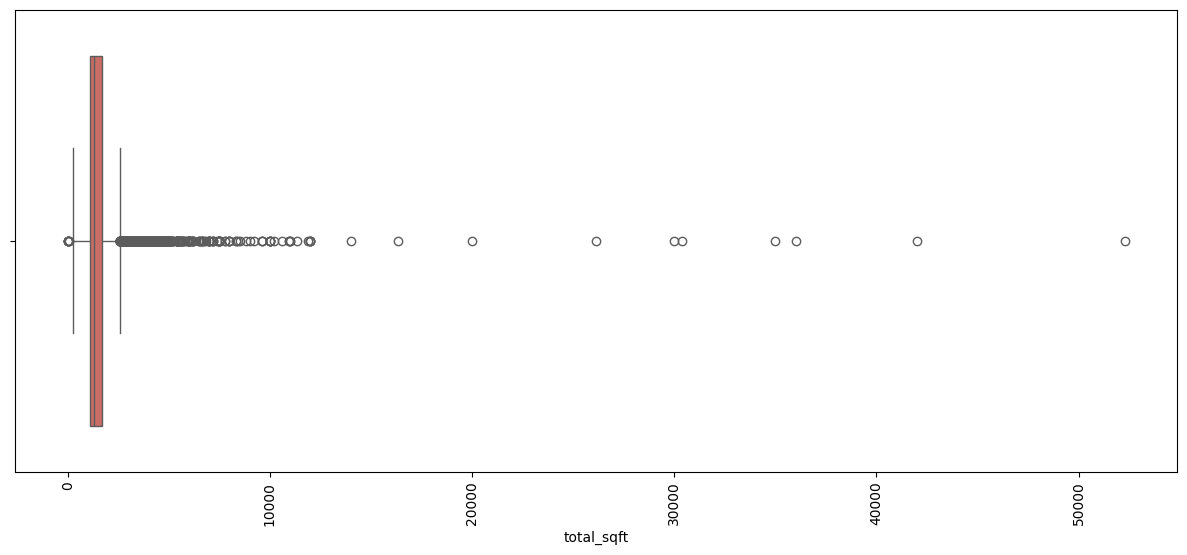

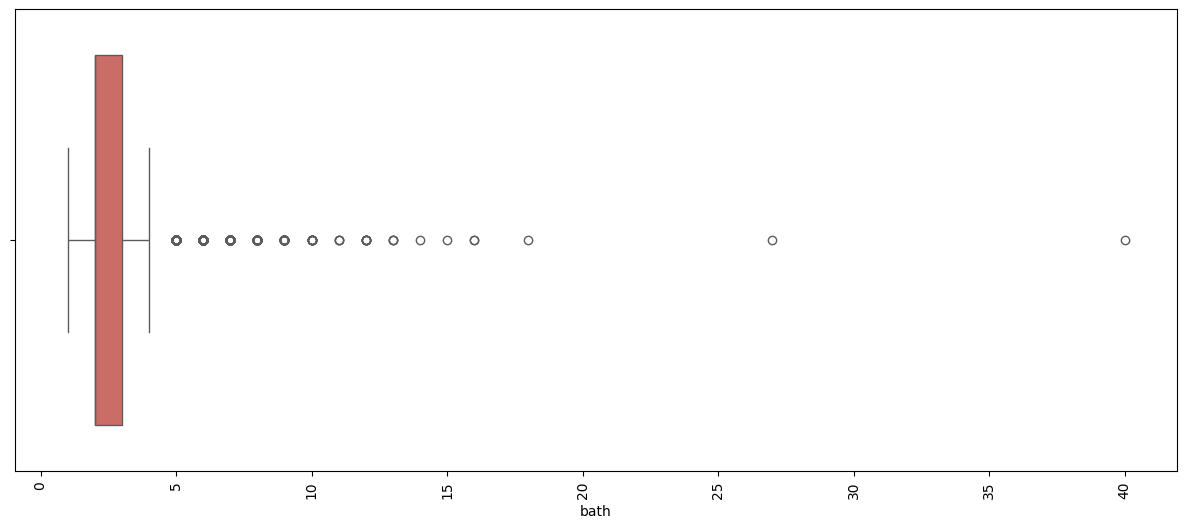

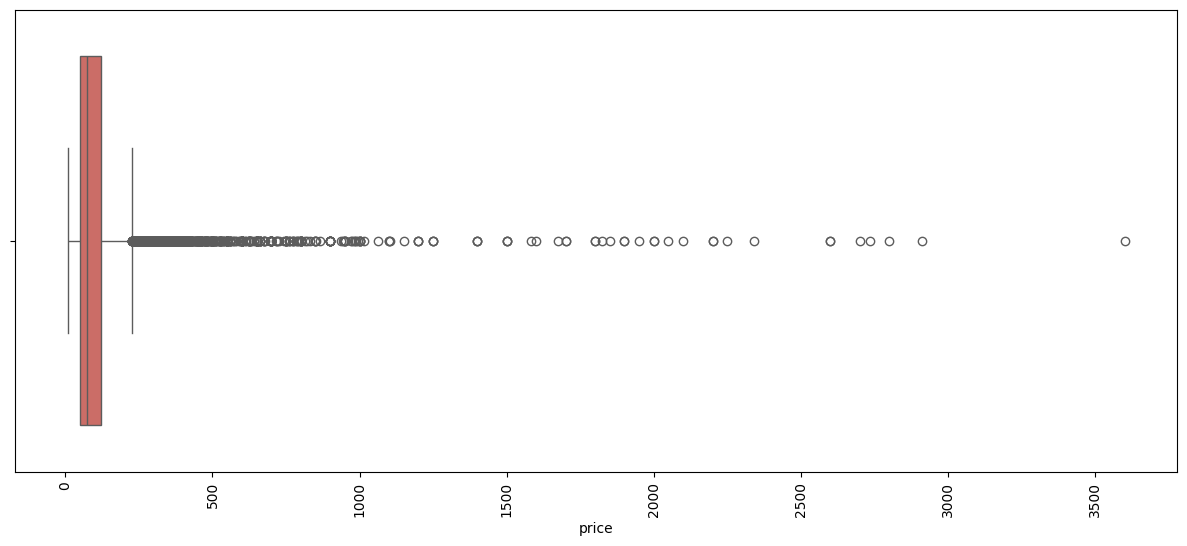

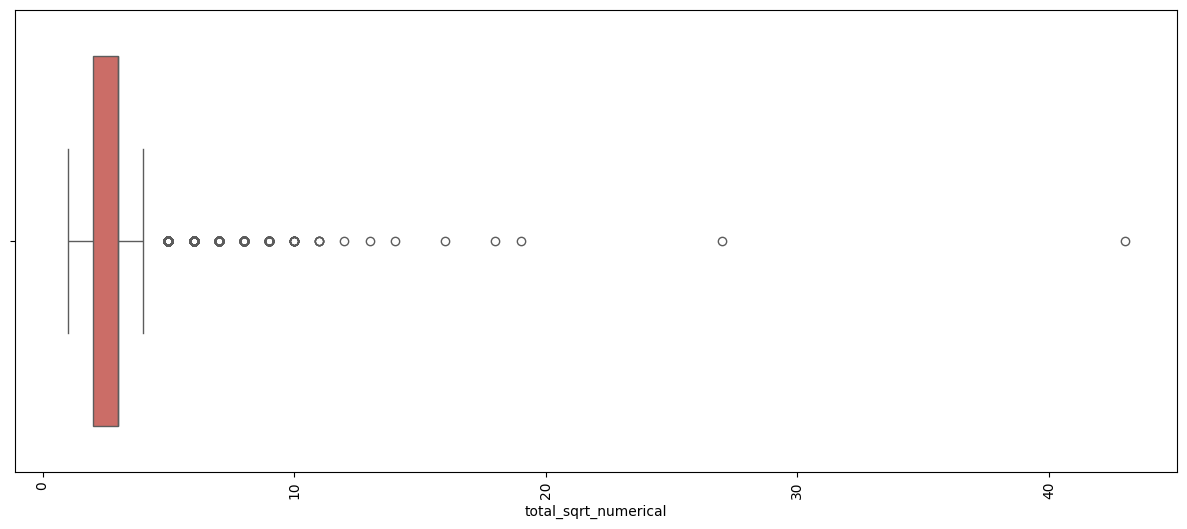

In [590]:
for i in continuous:
    plt.figure(figsize=(15, 6))
    sns.boxplot(x=i, data=df, palette='hls')
    plt.xticks(rotation=90)
    plt.show()

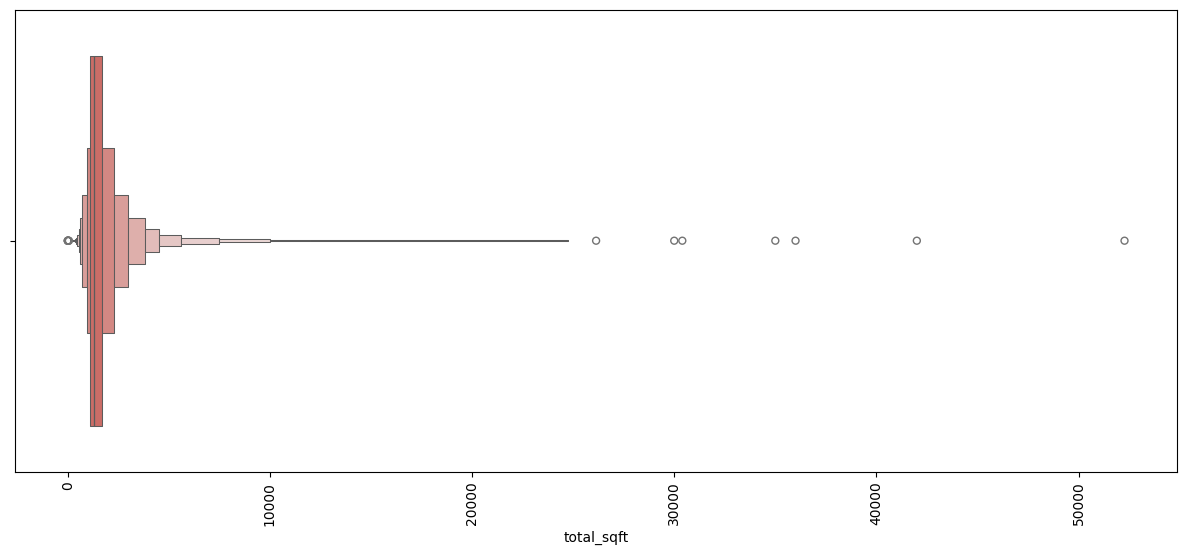

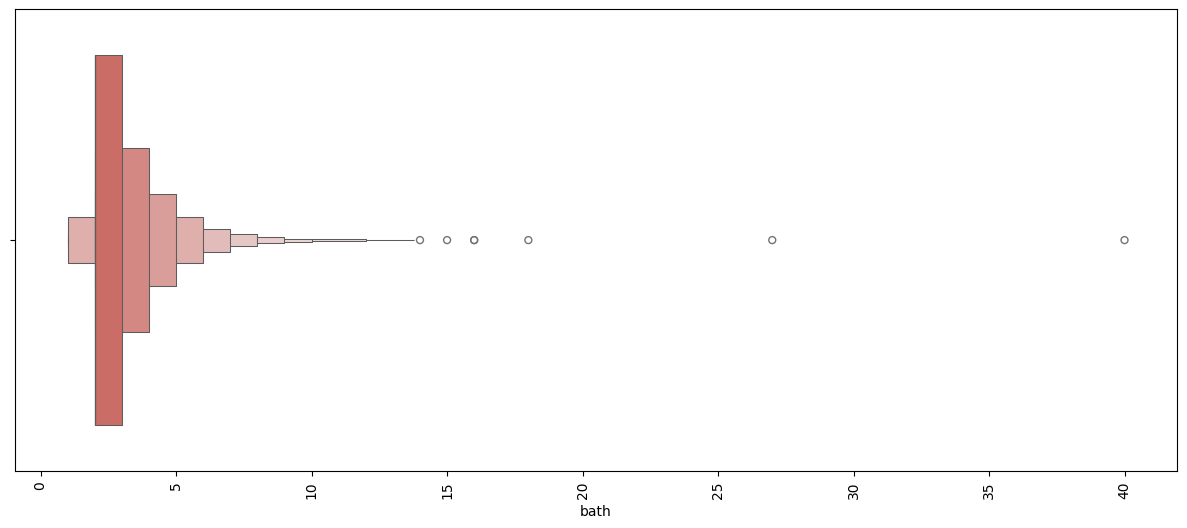

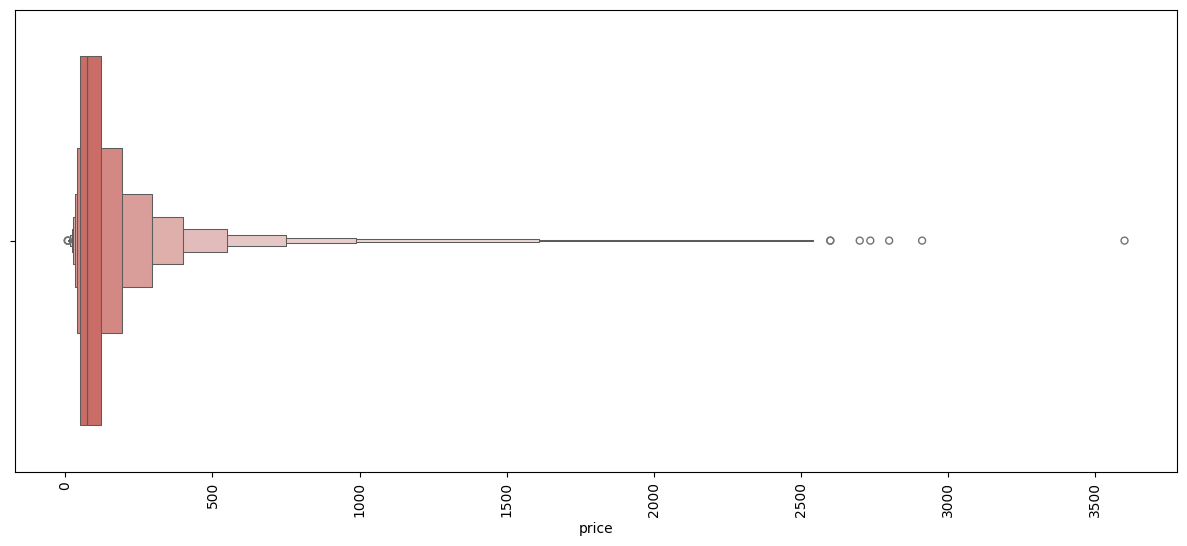

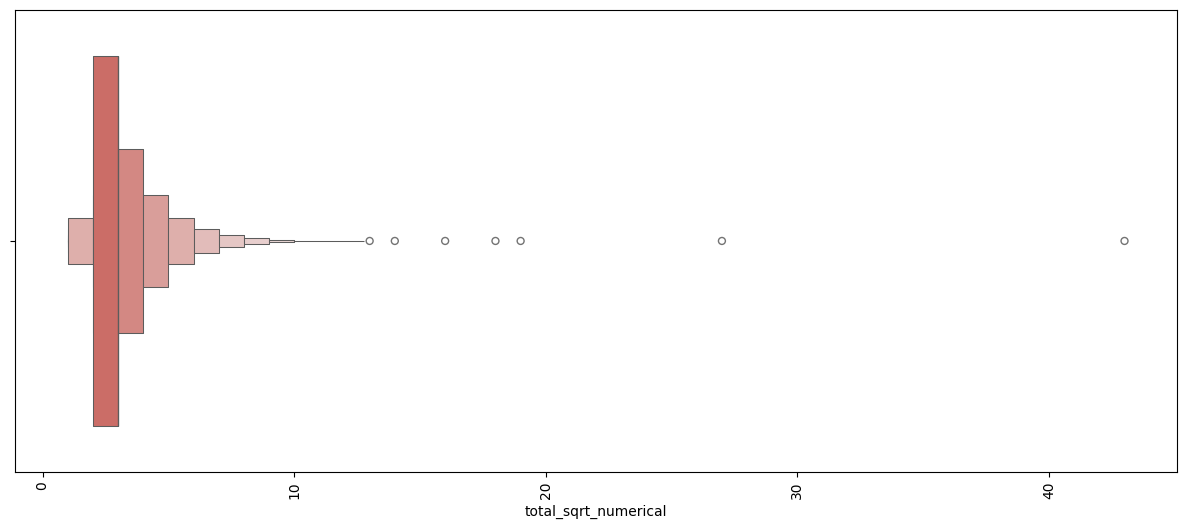

In [591]:
for i in continuous:
    plt.figure(figsize=(15, 6))
    sns.boxenplot(x=i, data=df, palette='hls')
    plt.xticks(rotation=90)
    plt.show()

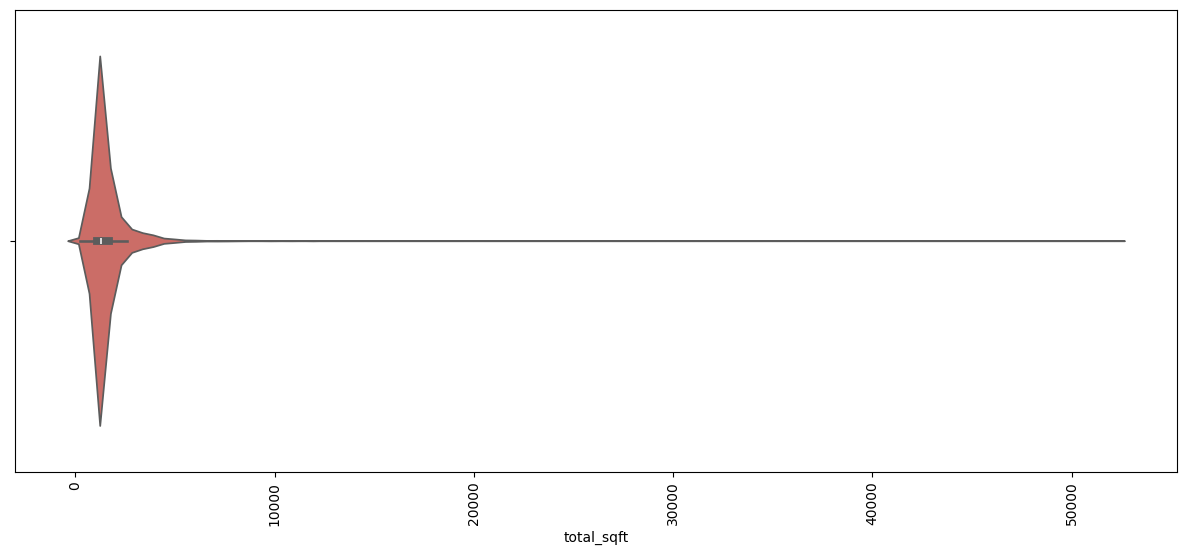

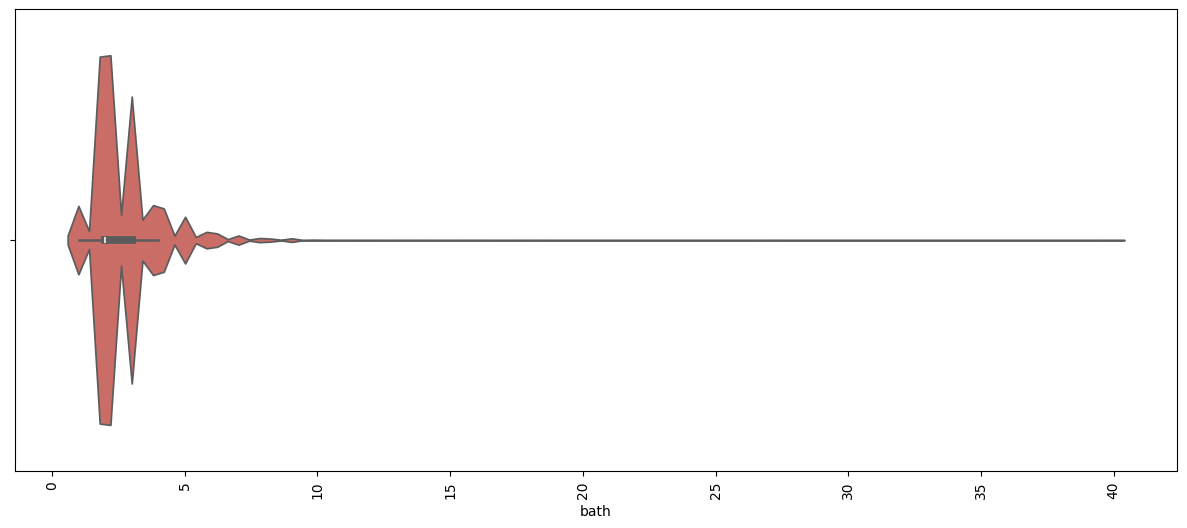

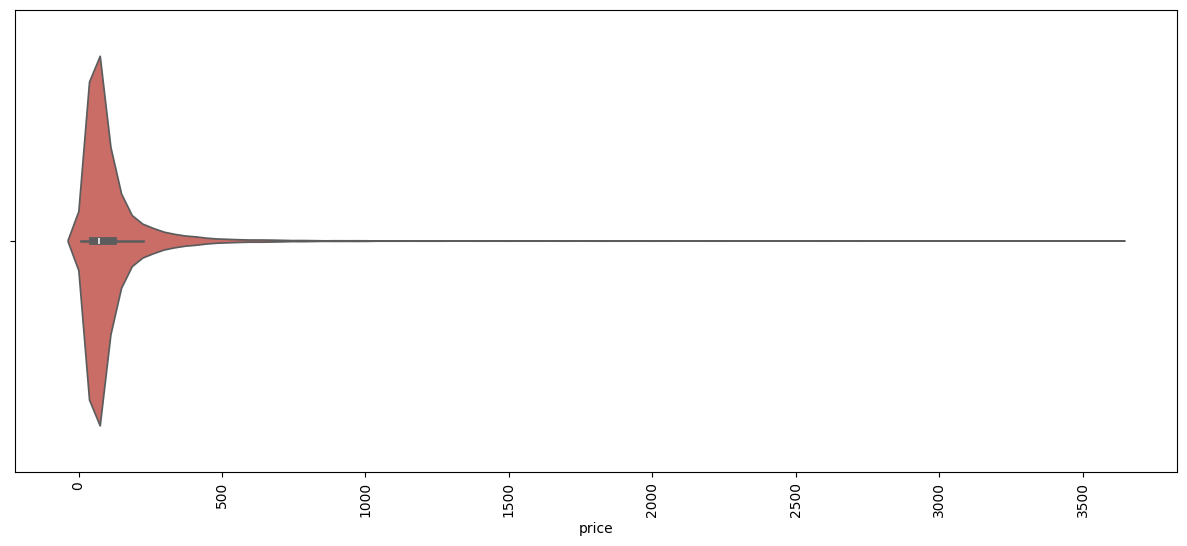

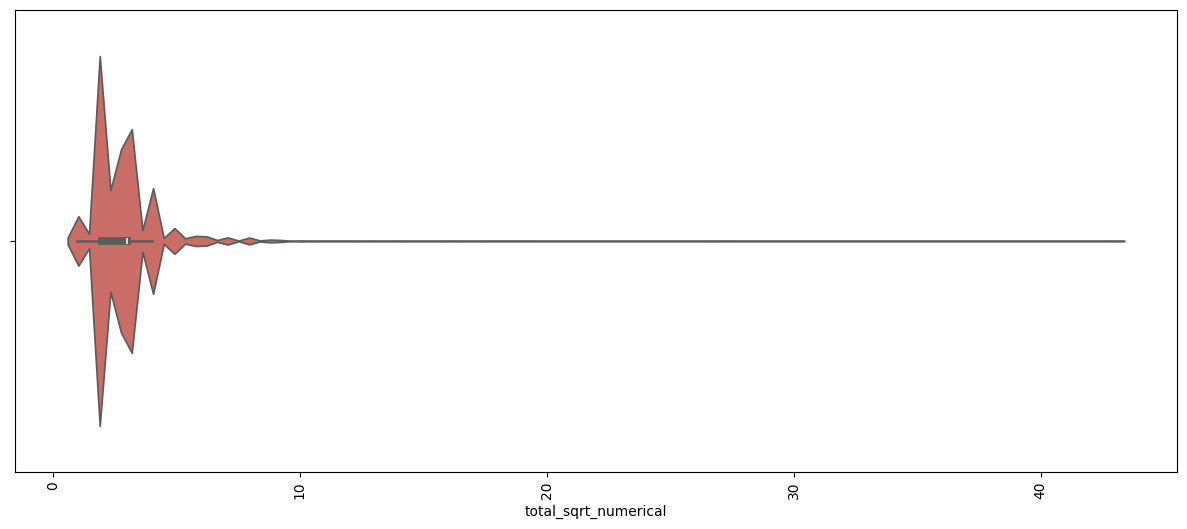

In [592]:
for i in continuous:
    plt.figure(figsize=(15, 6))
    sns.violinplot(x=i, data=df, palette='hls')
    plt.xticks(rotation=90)
    plt.show()

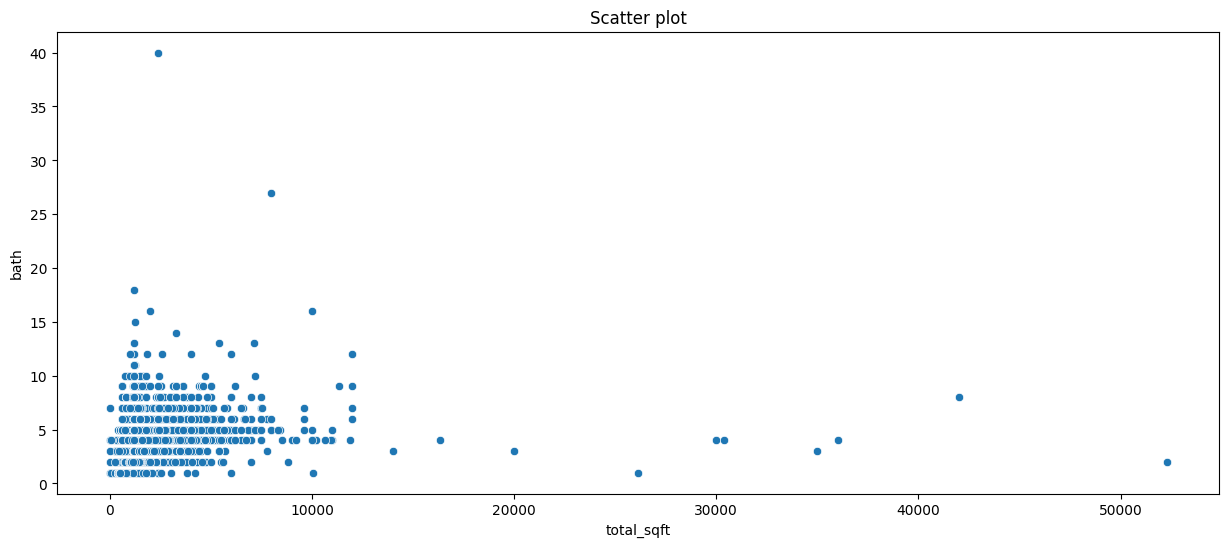

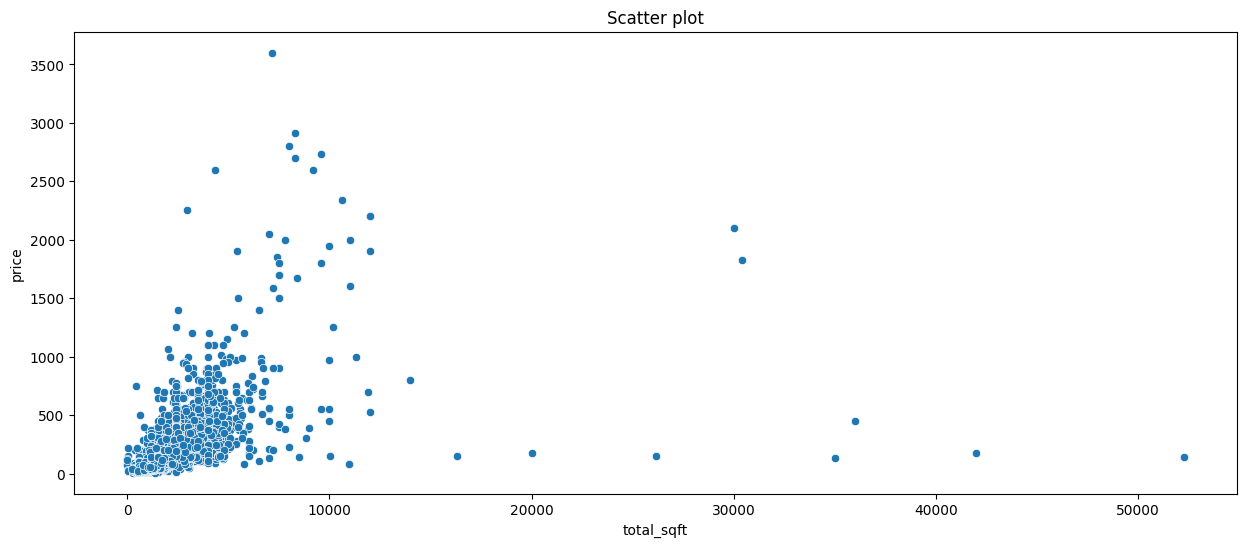

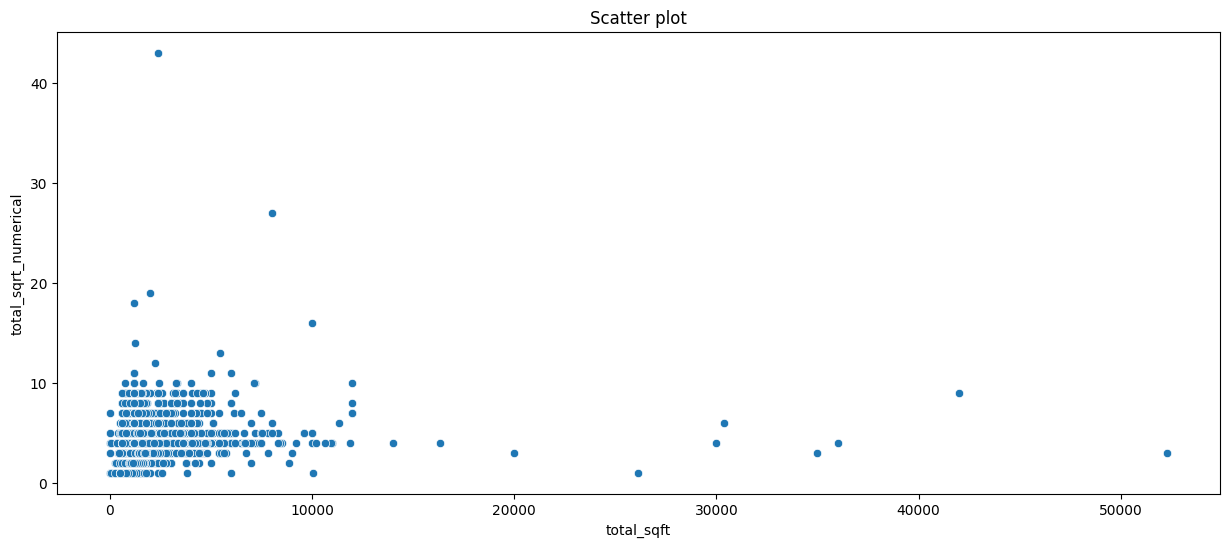

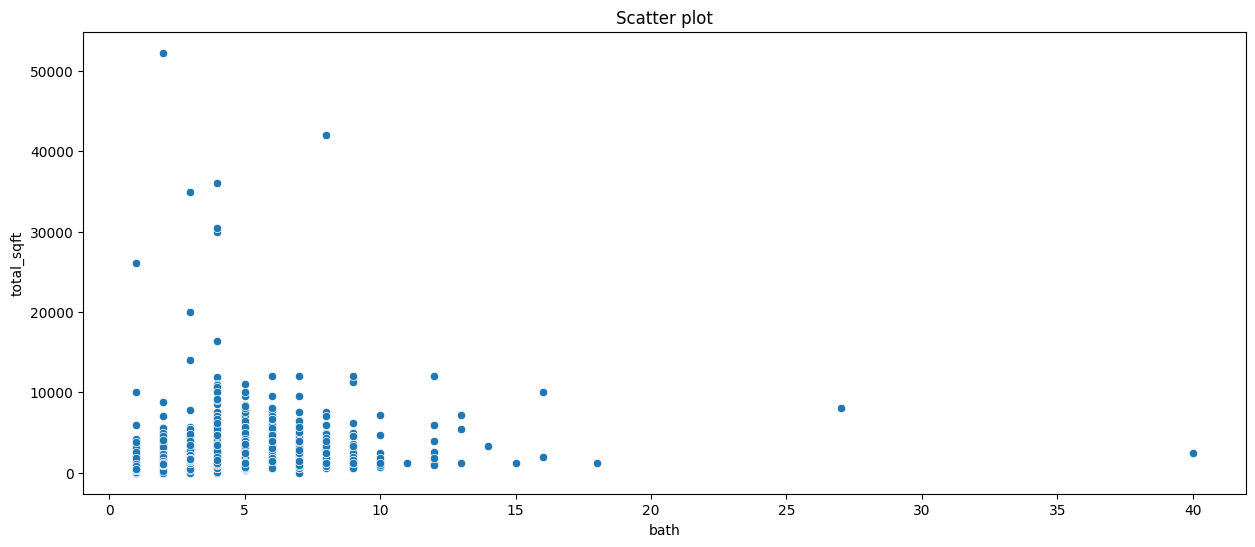

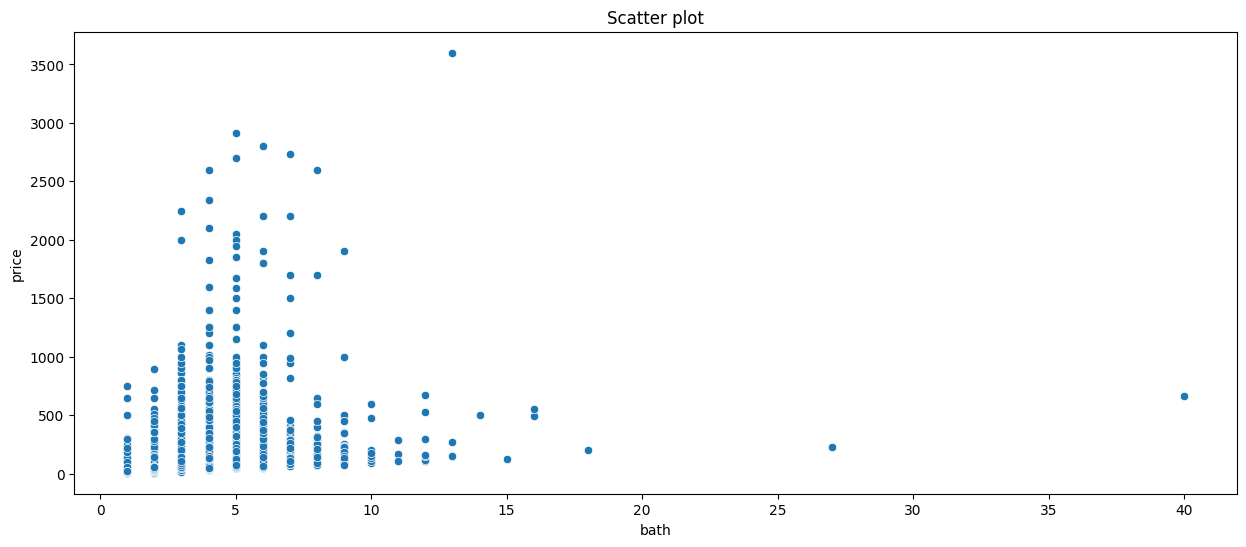

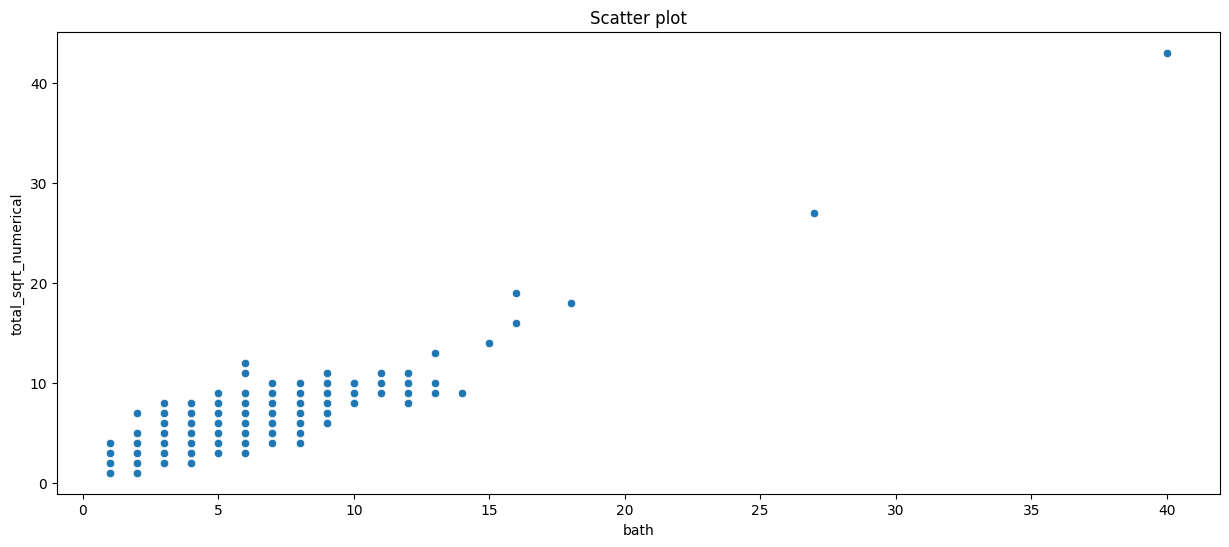

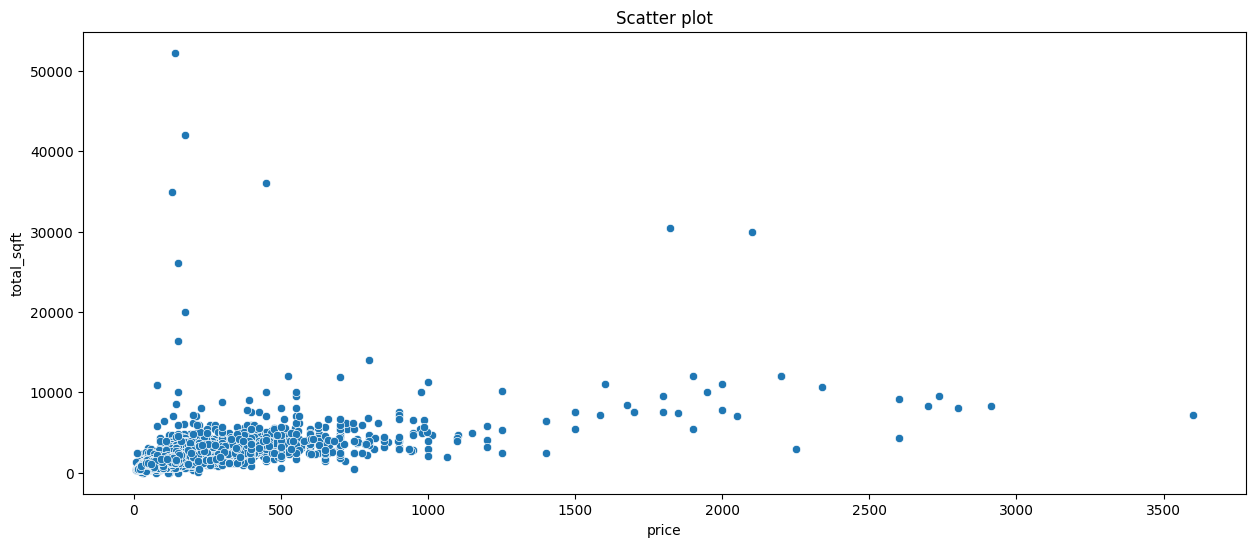

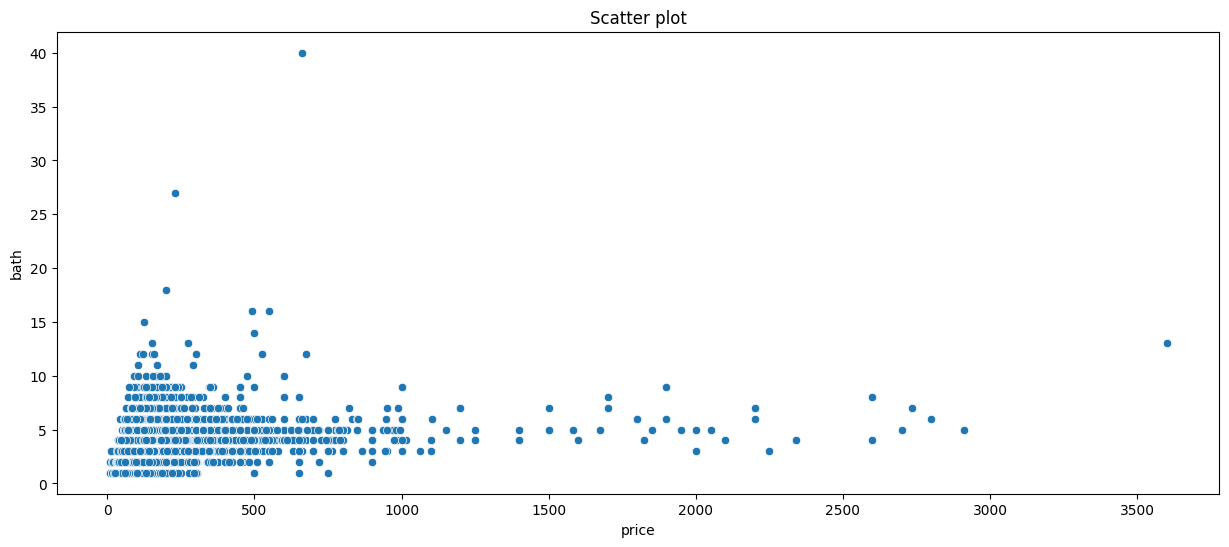

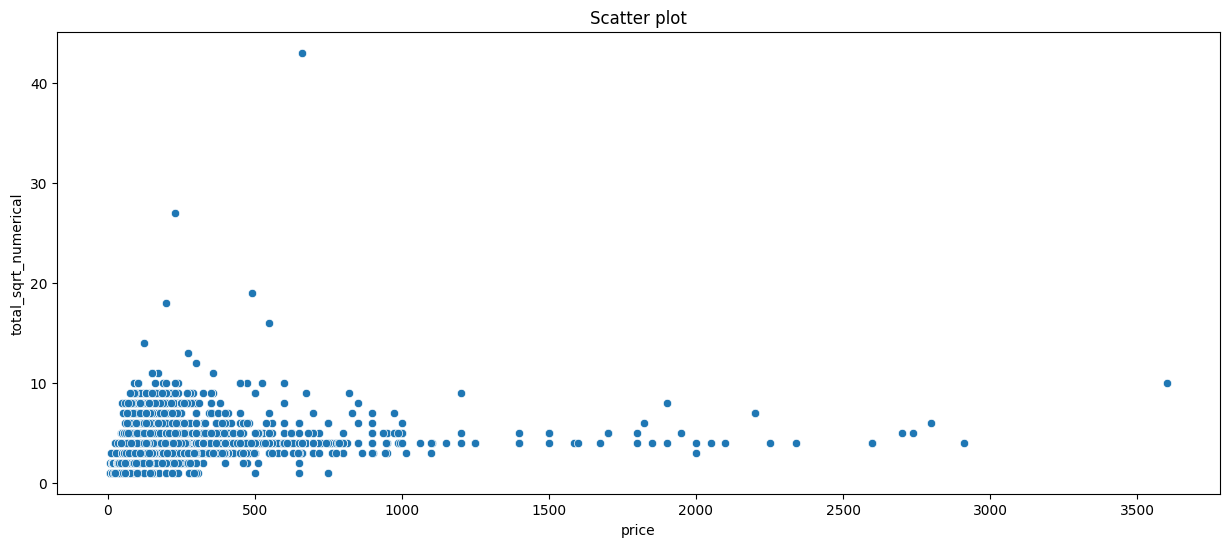

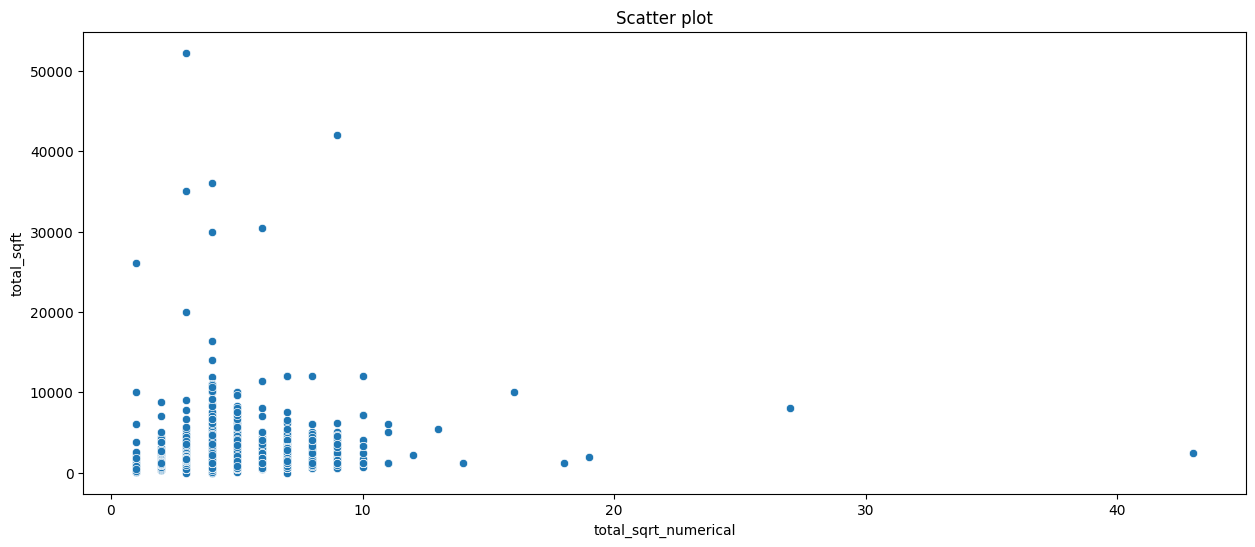

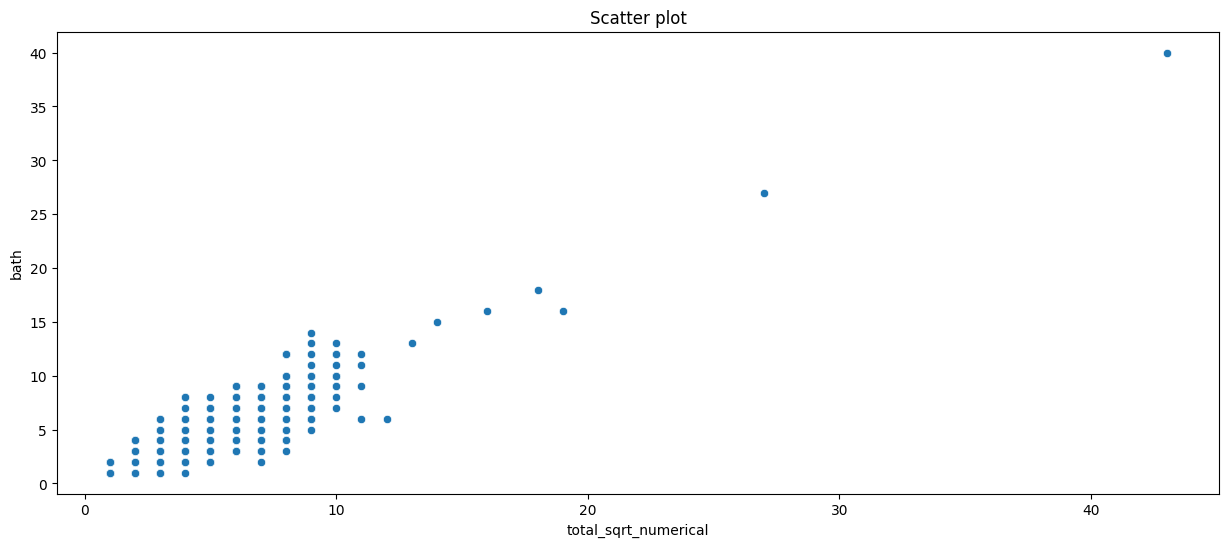

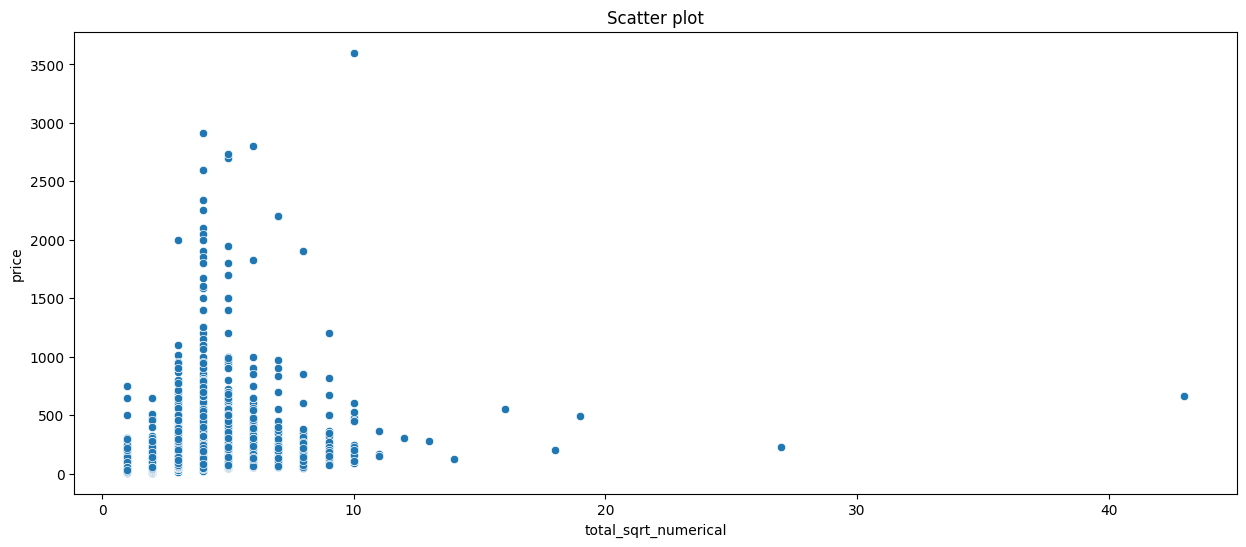

In [593]:
for i in continuous:
    for j in continuous:
        if i !=j:
            plt.figure(figsize=(15, 6))
            sns.scatterplot(x=i, y=j, data=df, palette='hls')
            plt.title(f'Scatter plot')
            plt.show()

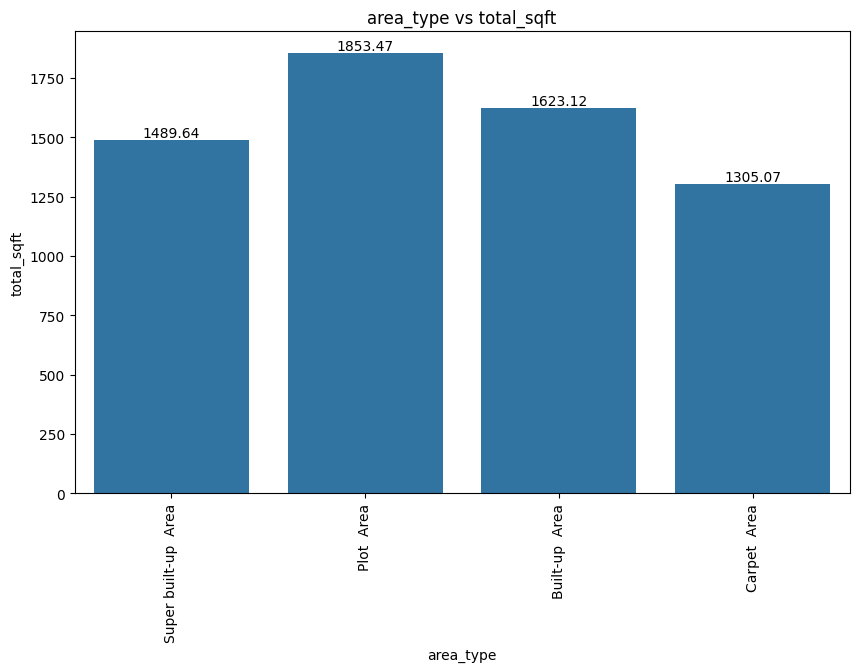

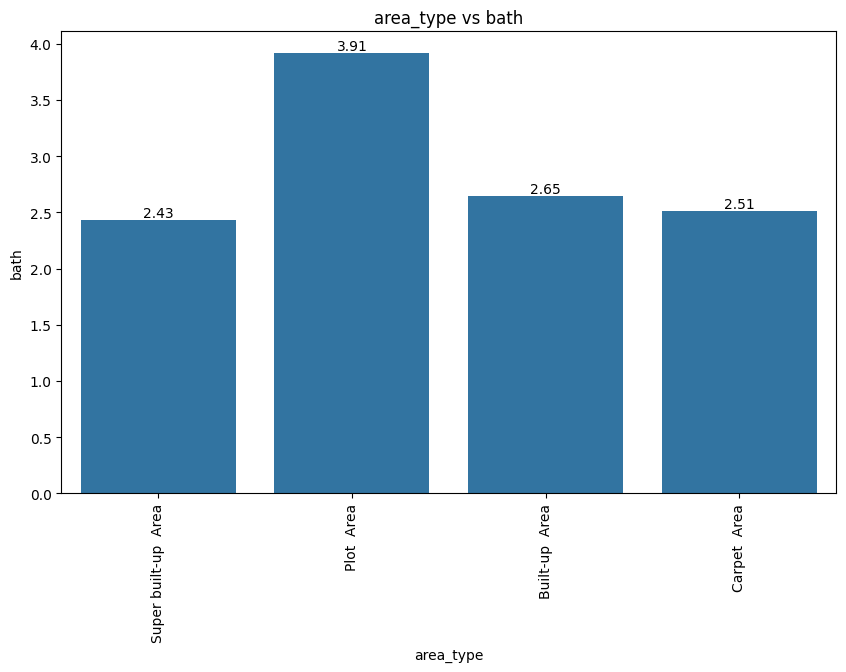

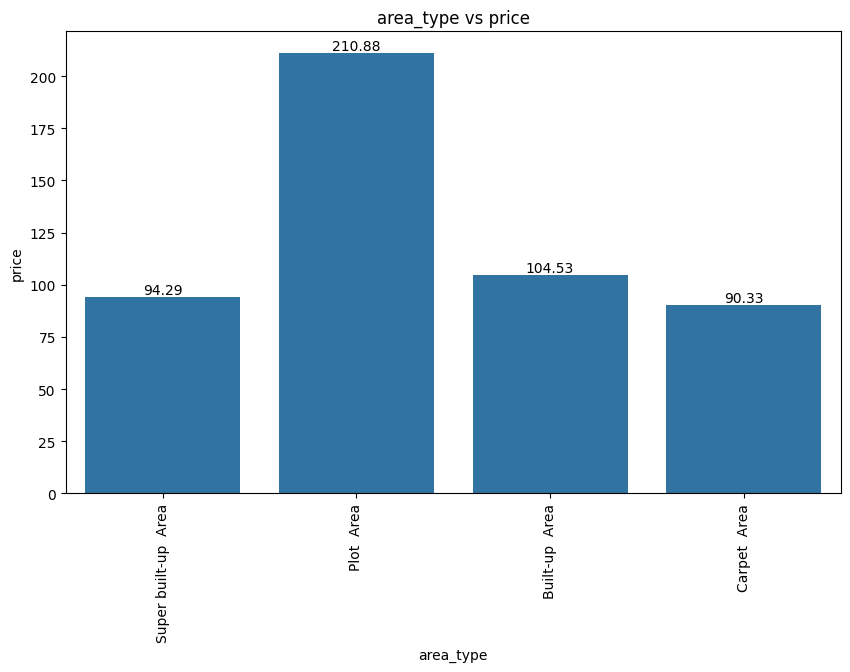

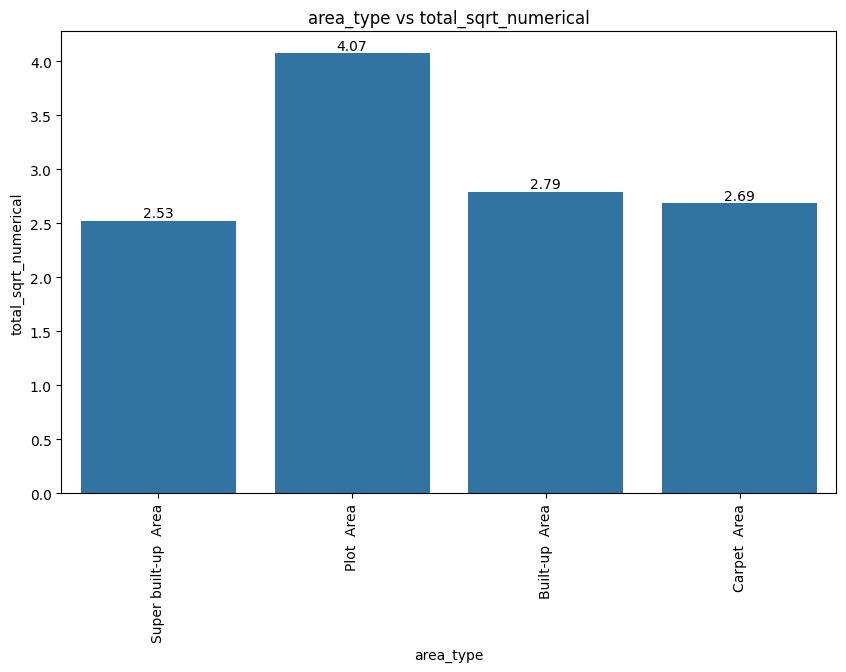

In [594]:
for cat in categorical:
    for cont in continuous:
        plt.figure(figsize=(10, 6))
        ax = sns.barplot(data=df, x=cat, y=cont, ci=None)
        plt.title(f'{cat} vs {cont}')
        
        for p in ax.patches:
            height = p.get_height()
            ax.annotate(f'{height:.2f}', (p.get_x() + p.get_width() / 2., height),
                        ha='center', va='bottom', fontsize=10, color='black', rotation=0)
        plt.xticks(rotation = 90)
        plt.show()

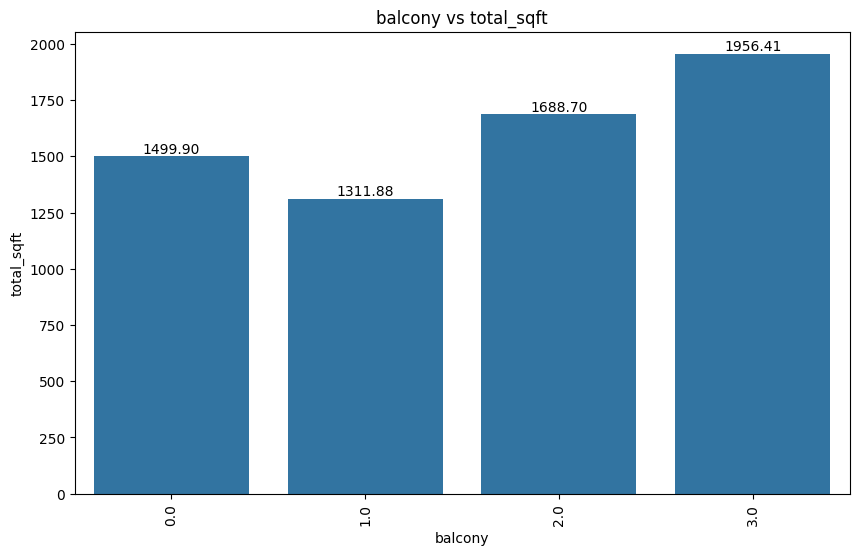

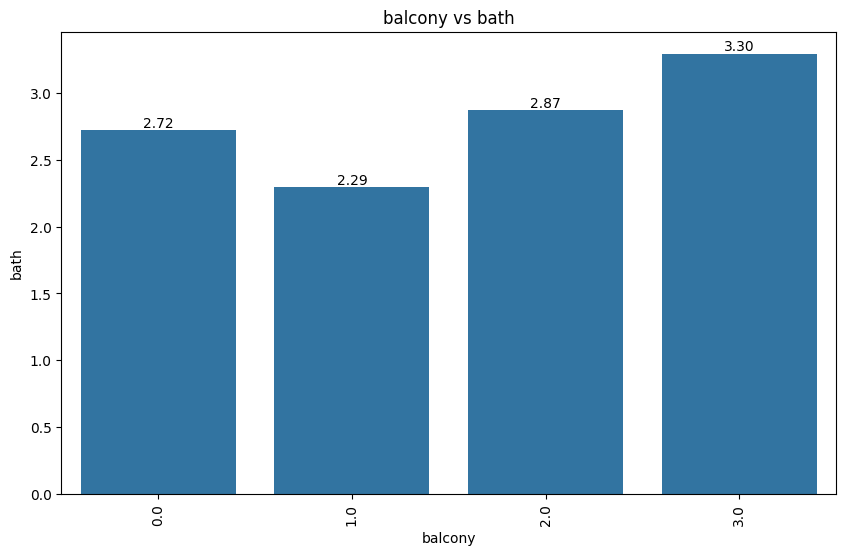

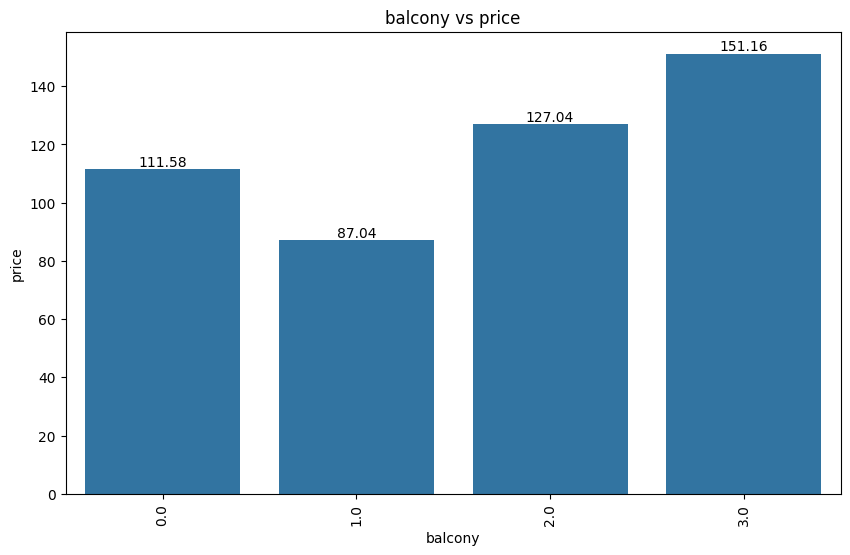

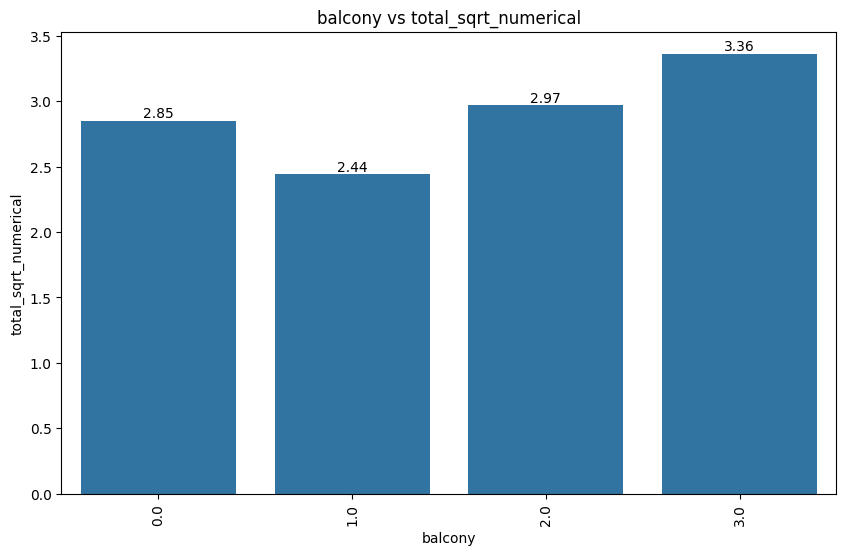

In [595]:
for cat in discrete:
    for cont in continuous:
        plt.figure(figsize=(10, 6))
        ax = sns.barplot(data=df, x=cat, y=cont, ci=None)
        plt.title(f'{cat} vs {cont}')
        
        for p in ax.patches:
            height = p.get_height()
            ax.annotate(f'{height:.2f}', (p.get_x() + p.get_width() / 2., height),
                        ha='center', va='bottom', fontsize=10, color='black', rotation=0)
        plt.xticks(rotation = 90)
        plt.show()

In [596]:
df

,area_type,availability,location,society,total_sqft,bath,balcony,price,total_sqrt_numerical
0,Super built-up Area,19-Dec,Electronic City Phase II,Coomee,1056.0,2.0,1.0,39.07,2.0
1,Plot Area,Ready To Move,Chikka Tirupathi,Theanmp,2600.0,5.0,3.0,120.00,4.0
2,Built-up Area,Ready To Move,Uttarahalli,Unknown,1440.0,2.0,3.0,62.00,3.0
3,Super built-up Area,Ready To Move,Lingadheeranahalli,Soiewre,1521.0,3.0,1.0,95.00,3.0
4,Super built-up Area,Ready To Move,Kothanur,Unknown,1200.0,2.0,1.0,51.00,2.0
...,...,...,...,...,...,...,...,...,...
13314,Super built-up Area,Ready To Move,Green Glen Layout,SoosePr,1715.0,3.0,3.0,112.00,3.0
13315,Built-up Area,Ready To Move,Whitefield,ArsiaEx,3453.0,4.0,0.0,231.00,5.0
13316,Super built-up Area,Ready To Move,Richards Town,Unknown,3600.0,5.0,2.0,400.00,4.0
13317,Built-up Area,Ready To Move,Raja Rajeshwari Nagar,Mahla T,1141.0,2.0,1.0,60.00,2.0


In [597]:
df['price_per_sqft']=df['price']*100000/df['total_sqft']

In [598]:
df.head()

,area_type,availability,location,society,total_sqft,bath,balcony,price,total_sqrt_numerical,price_per_sqft
0,Super built-up Area,19-Dec,Electronic City Phase II,Coomee,1056.0,2.0,1.0,39.07,2.0,3699.810606
1,Plot Area,Ready To Move,Chikka Tirupathi,Theanmp,2600.0,5.0,3.0,120.00,4.0,4615.384615
2,Built-up Area,Ready To Move,Uttarahalli,Unknown,1440.0,2.0,3.0,62.00,3.0,4305.555556
3,Super built-up Area,Ready To Move,Lingadheeranahalli,Soiewre,1521.0,3.0,1.0,95.00,3.0,6245.890861
4,Super built-up Area,Ready To Move,Kothanur,Unknown,1200.0,2.0,1.0,51.00,2.0,4250.000000


In [599]:
df['location'].value_counts()

location
Whitefield                        522
Sarjapur  Road                    379
Electronic City                   287
Kanakpura Road                    247
Thanisandra                       228
                                 ... 
1st Stage Radha Krishna Layout      1
BEML Layout 5th stage               1
Kannur                              1
singapura paradise                  1
Abshot Layout                       1
Name: count, Length: 1299, dtype: int64

In [600]:
location_stats = df['location'].value_counts()

In [601]:
len(location_stats[location_stats<=20])

1160

In [602]:
locationlessthan20=location_stats[location_stats<=20]
locationlessthan20

location
Binny Pete                        20
Kogilu                            20
Yelachenahalli                    20
Sanjay nagar                      20
HBR Layout                        20
                                  ..
1st Stage Radha Krishna Layout     1
BEML Layout 5th stage              1
Kannur                             1
singapura paradise                 1
Abshot Layout                      1
Name: count, Length: 1160, dtype: int64

In [603]:
len(df.location.unique())

1299

In [604]:
df.location=df.location.apply(lambda x: 'other' if x in locationlessthan20 else x)
len(df.location.unique())

140

In [605]:
df.head()

,area_type,availability,location,society,total_sqft,bath,balcony,price,total_sqrt_numerical,price_per_sqft
0,Super built-up Area,19-Dec,Electronic City Phase II,Coomee,1056.0,2.0,1.0,39.07,2.0,3699.810606
1,Plot Area,Ready To Move,other,Theanmp,2600.0,5.0,3.0,120.00,4.0,4615.384615
2,Built-up Area,Ready To Move,Uttarahalli,Unknown,1440.0,2.0,3.0,62.00,3.0,4305.555556
3,Super built-up Area,Ready To Move,Lingadheeranahalli,Soiewre,1521.0,3.0,1.0,95.00,3.0,6245.890861
4,Super built-up Area,Ready To Move,Kothanur,Unknown,1200.0,2.0,1.0,51.00,2.0,4250.000000


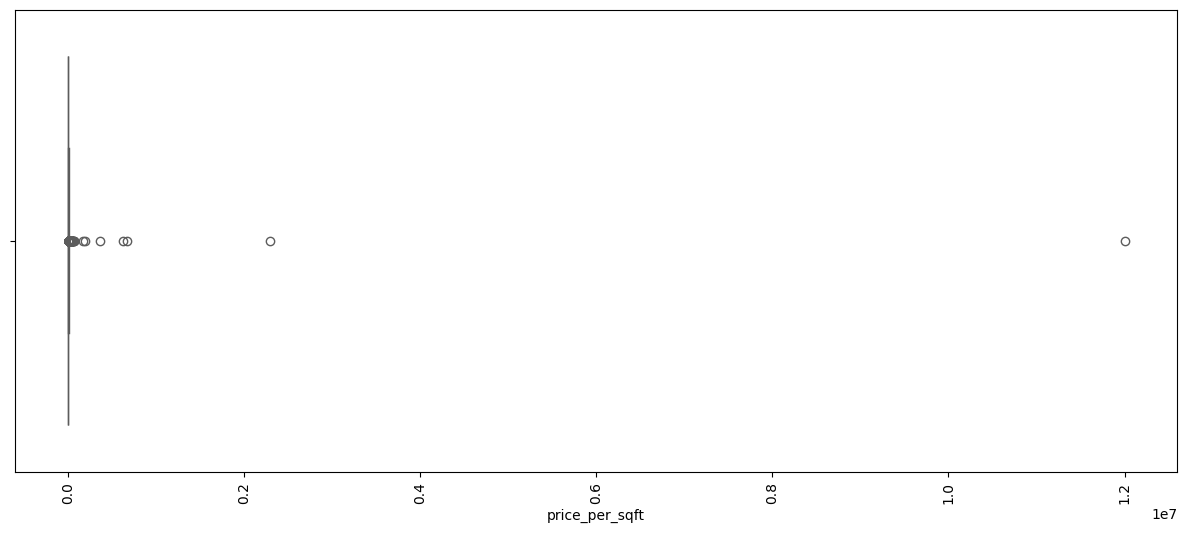

In [606]:
plt.figure(figsize=(15,6))
sns.boxplot(x = df['price_per_sqft'], data = df, palette='hls')
plt.xticks(rotation = 90)
plt.show()

In [607]:
df.columns

Index(['area_type', 'availability', 'location', 'society', 'total_sqft',
       'bath', 'balcony', 'price', 'total_sqrt_numerical', 'price_per_sqft'],
      dtype='object')

In [608]:
df1 = df[['total_sqft','bath', 'balcony', 'price', 'total_sqrt_numerical', 'price_per_sqft']]

In [609]:
Q1 = df1.quantile(0.25)
Q3 = df1.quantile(0.75)
IQR = Q3 - Q1

In [610]:
Q1

total_sqft              1100.000000
bath                       2.000000
balcony                    1.000000
price                     50.000000
total_sqrt_numerical       2.000000
price_per_sqft          4298.558682
Name: 0.25, dtype: float64

In [611]:
Q3

total_sqft              1691.000000
bath                       3.000000
balcony                    2.000000
price                    120.000000
total_sqrt_numerical       3.000000
price_per_sqft          7398.708162
Name: 0.75, dtype: float64

In [612]:
IQR

total_sqft               591.00000
bath                       1.00000
balcony                    1.00000
price                     70.00000
total_sqrt_numerical       1.00000
price_per_sqft          3100.14948
dtype: float64

In [613]:
x = Q1 - 1.5 * IQR

In [614]:
x

total_sqft              213.500000
bath                      0.500000
balcony                  -0.500000
price                   -55.000000
total_sqrt_numerical      0.500000
price_per_sqft         -351.665538
dtype: float64

In [615]:
x = Q3 + 1.5 * IQR

In [616]:
x

total_sqft               2577.500000
bath                        4.500000
balcony                     3.500000
price                     225.000000
total_sqrt_numerical        4.500000
price_per_sqft          12048.932382
dtype: float64

In [617]:
# this is 1.5 rule or Turkish Rule for outlier removal

In [618]:
df = df[~((df1 < (Q1 - 1.5 * IQR)) | (df1 > (Q3 + 1.5 * IQR))).any(axis = 1)]

In [619]:
df

,area_type,availability,location,society,total_sqft,bath,balcony,price,total_sqrt_numerical,price_per_sqft
0,Super built-up Area,19-Dec,Electronic City Phase II,Coomee,1056.0,2.0,1.0,39.07,2.0,3699.810606
2,Built-up Area,Ready To Move,Uttarahalli,Unknown,1440.0,2.0,3.0,62.00,3.0,4305.555556
3,Super built-up Area,Ready To Move,Lingadheeranahalli,Soiewre,1521.0,3.0,1.0,95.00,3.0,6245.890861
4,Super built-up Area,Ready To Move,Kothanur,Unknown,1200.0,2.0,1.0,51.00,2.0,4250.000000
5,Super built-up Area,Ready To Move,Whitefield,DuenaTa,1170.0,2.0,1.0,38.00,2.0,3247.863248
...,...,...,...,...,...,...,...,...,...,...
13309,Super built-up Area,Ready To Move,Yeshwanthpur,IBityin,1675.0,3.0,2.0,92.13,3.0,5500.298507
13310,Super built-up Area,Ready To Move,Rachenahalli,Unknown,1050.0,2.0,2.0,52.71,2.0,5020.000000
13312,Super built-up Area,Ready To Move,Bellandur,Unknown,1262.0,2.0,2.0,47.00,2.0,3724.247227
13314,Super built-up Area,Ready To Move,Green Glen Layout,SoosePr,1715.0,3.0,3.0,112.00,3.0,6530.612245


In [620]:
df.duplicated().sum()

51

In [621]:
df = df.drop_duplicates()

In [622]:
df.isnull().sum()

area_type               0
availability            0
location                0
society                 0
total_sqft              0
bath                    0
balcony                 0
price                   0
total_sqrt_numerical    0
price_per_sqft          0
dtype: int64

In [623]:
corr = df1.corr()

In [624]:
corr

,total_sqft,bath,balcony,price,total_sqrt_numerical,price_per_sqft
total_sqft,1.000000,0.385607,0.152439,0.574008,0.344206,-0.008566
bath,0.385607,1.000000,0.204059,0.450843,0.896237,0.030613
balcony,0.152439,0.204059,1.000000,0.123506,0.190676,0.009317
price,0.574008,0.450843,0.123506,1.000000,0.394577,0.027975
total_sqrt_numerical,0.344206,0.896237,0.190676,0.394577,1.000000,0.030628
price_per_sqft,-0.008566,0.030613,0.009317,0.027975,0.030628,1.000000


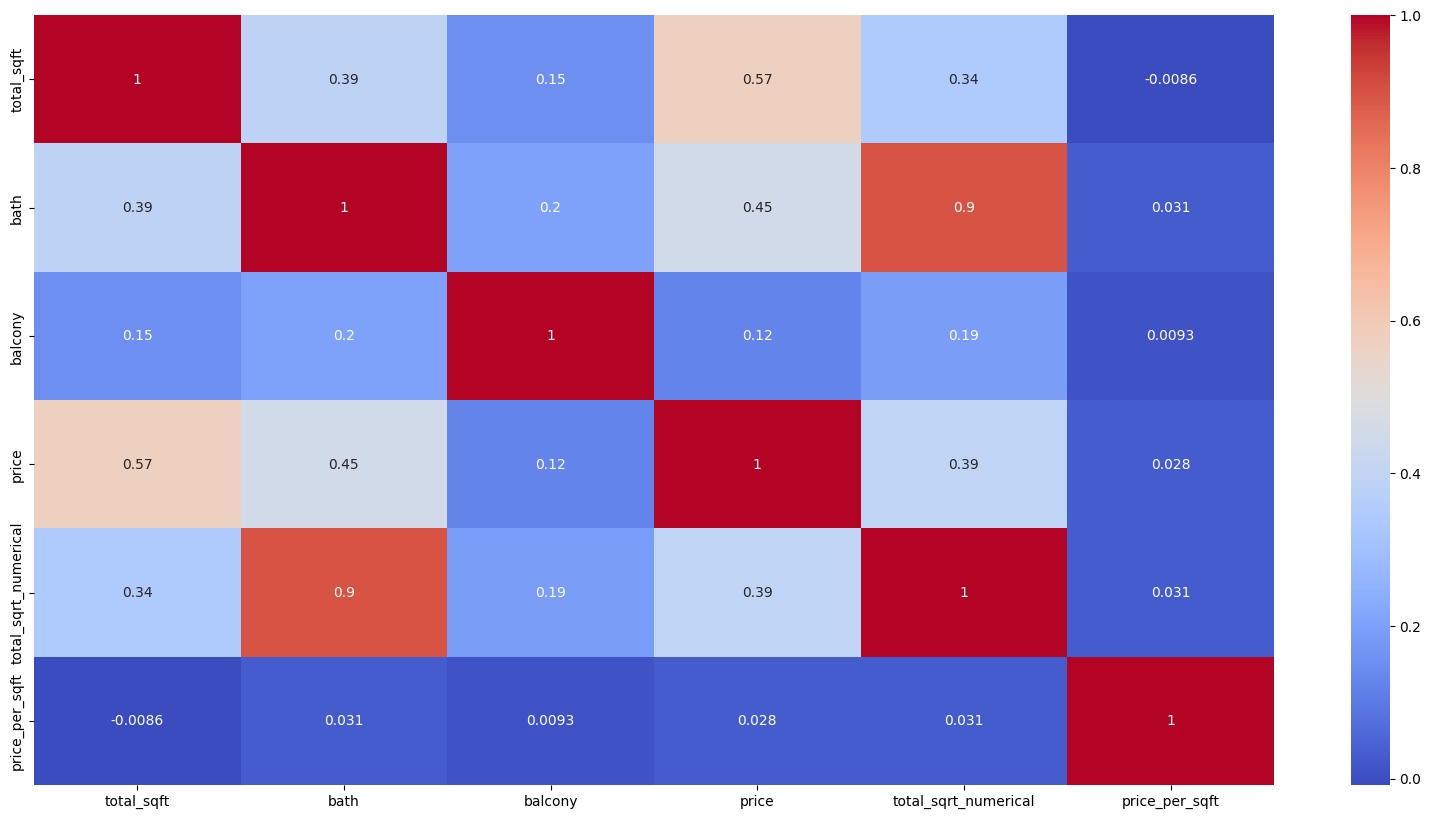

In [625]:
plt.figure(figsize=(20,10))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()

In [626]:
df = df.drop('total_sqrt_numerical', axis = 1)

In [627]:
df = df.drop('price', axis = 1)

In [628]:
df = df.drop('society', axis = 1)

In [629]:
df

,area_type,availability,location,total_sqft,bath,balcony,price_per_sqft
0,Super built-up Area,19-Dec,Electronic City Phase II,1056.0,2.0,1.0,3699.810606
2,Built-up Area,Ready To Move,Uttarahalli,1440.0,2.0,3.0,4305.555556
3,Super built-up Area,Ready To Move,Lingadheeranahalli,1521.0,3.0,1.0,6245.890861
4,Super built-up Area,Ready To Move,Kothanur,1200.0,2.0,1.0,4250.000000
5,Super built-up Area,Ready To Move,Whitefield,1170.0,2.0,1.0,3247.863248
...,...,...,...,...,...,...,...
13309,Super built-up Area,Ready To Move,Yeshwanthpur,1675.0,3.0,2.0,5500.298507
13310,Super built-up Area,Ready To Move,Rachenahalli,1050.0,2.0,2.0,5020.000000
13312,Super built-up Area,Ready To Move,Bellandur,1262.0,2.0,2.0,3724.247227
13314,Super built-up Area,Ready To Move,Green Glen Layout,1715.0,3.0,3.0,6530.612245


In [630]:
df.columns

Index(['area_type', 'availability', 'location', 'total_sqft', 'bath',
       'balcony', 'price_per_sqft'],
      dtype='object')

In [631]:
df2 = df[['total_sqft', 'bath', 'balcony', 'price_per_sqft']]

In [633]:
Q1 = df2.quantile(0.25)
Q3 = df2.quantile(0.75)
IQR = Q3 - Q1

In [634]:
df = df[~((df2 < (Q1 - 1.5 * IQR)) | (df2 > (Q3 + 1.5 * IQR))).any(axis = 1)]

In [635]:
df

,area_type,availability,location,total_sqft,bath,balcony,price_per_sqft
0,Super built-up Area,19-Dec,Electronic City Phase II,1056.0,2.0,1.0,3699.810606
2,Built-up Area,Ready To Move,Uttarahalli,1440.0,2.0,3.0,4305.555556
3,Super built-up Area,Ready To Move,Lingadheeranahalli,1521.0,3.0,1.0,6245.890861
4,Super built-up Area,Ready To Move,Kothanur,1200.0,2.0,1.0,4250.000000
5,Super built-up Area,Ready To Move,Whitefield,1170.0,2.0,1.0,3247.863248
...,...,...,...,...,...,...,...
13309,Super built-up Area,Ready To Move,Yeshwanthpur,1675.0,3.0,2.0,5500.298507
13310,Super built-up Area,Ready To Move,Rachenahalli,1050.0,2.0,2.0,5020.000000
13312,Super built-up Area,Ready To Move,Bellandur,1262.0,2.0,2.0,3724.247227
13314,Super built-up Area,Ready To Move,Green Glen Layout,1715.0,3.0,3.0,6530.612245


In [636]:
df.nunique()

area_type            4
availability        79
location           140
total_sqft        1347
bath                 4
balcony              4
price_per_sqft    6044
dtype: int64

In [637]:
df['availability']=df['availability'].apply(lambda x: 'Not Ready' if x != 'Ready To Move' else x)

In [638]:
df.nunique()

area_type            4
availability         2
location           140
total_sqft        1347
bath                 4
balcony              4
price_per_sqft    6044
dtype: int64

In [639]:
df = pd.get_dummies(df, columns=['area_type', 'availability', 'location'])

In [640]:
df

,total_sqft,bath,balcony,price_per_sqft,area_type_Built-up Area,area_type_Carpet Area,area_type_Plot Area,area_type_Super built-up Area,availability_Not Ready,availability_Ready To Move,...,location_Uttarahalli,location_Varthur,location_Vidyaranyapura,location_Vijayanagar,location_Vittasandra,location_Whitefield,location_Yelahanka,location_Yelahanka New Town,location_Yeshwanthpur,location_other
0,1056.0,2.0,1.0,3699.810606,False,False,False,True,True,False,...,False,False,False,False,False,False,False,False,False,False
2,1440.0,2.0,3.0,4305.555556,True,False,False,False,False,True,...,True,False,False,False,False,False,False,False,False,False
3,1521.0,3.0,1.0,6245.890861,False,False,False,True,False,True,...,False,False,False,False,False,False,False,False,False,False
4,1200.0,2.0,1.0,4250.000000,False,False,False,True,False,True,...,False,False,False,False,False,False,False,False,False,False
5,1170.0,2.0,1.0,3247.863248,False,False,False,True,False,True,...,False,False,False,False,False,True,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13309,1675.0,3.0,2.0,5500.298507,False,False,False,True,False,True,...,False,False,False,False,False,False,False,False,True,False
13310,1050.0,2.0,2.0,5020.000000,False,False,False,True,False,True,...,False,False,False,False,False,False,False,False,False,False
13312,1262.0,2.0,2.0,3724.247227,False,False,False,True,False,True,...,False,False,False,False,False,False,False,False,False,False
13314,1715.0,3.0,3.0,6530.612245,False,False,False,True,False,True,...,False,False,False,False,False,False,False,False,False,False


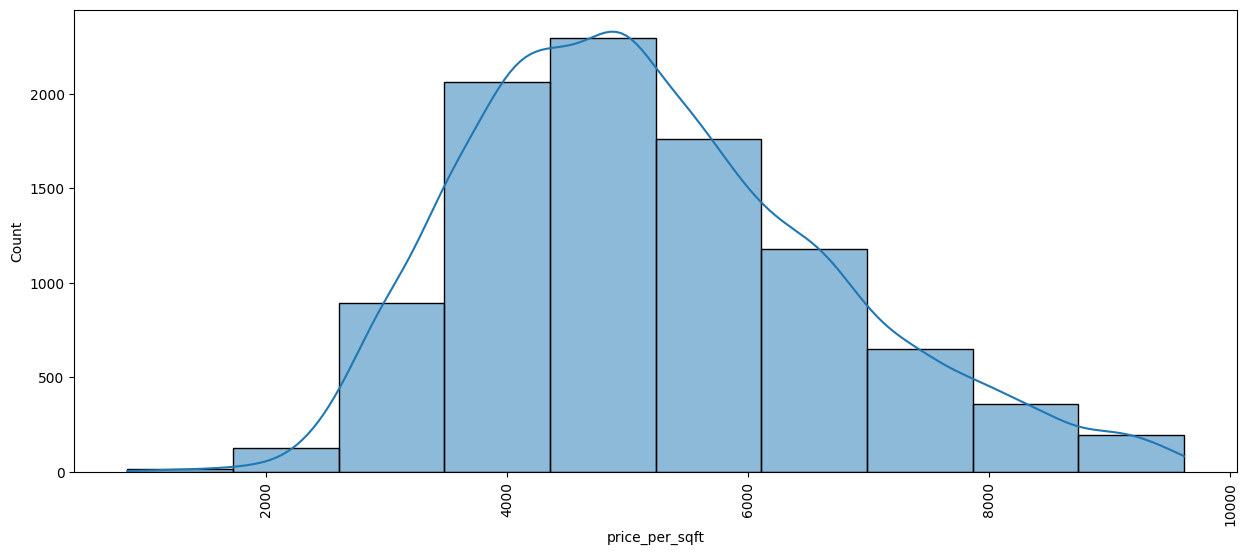

In [641]:
plt.figure(figsize=(15,6))
sns.histplot(df['price_per_sqft'], bins = 10, kde = True, palette='hls')
plt.xticks(rotation = 90)
plt.show()

In [642]:
df['price_per_sqft'] = np.log(df['price_per_sqft'])

In [643]:
df['total_sqft'] = np.log(df['total_sqft'])

In [644]:
X = df.drop(['price_per_sqft'], axis = 1)

In [645]:
y =  df['price_per_sqft']

In [646]:
from sklearn.model_selection import train_test_split

In [647]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, shuffle = True,
                                                    random_state=42)

In [648]:
from sklearn.linear_model import LinearRegression
model=LinearRegression()

In [649]:
model.fit(X_train,y_train)

LinearRegression()

In [651]:
y_pred = model.predict(X_test)

In [652]:
from sklearn.metrics import mean_squared_error, r2_score

In [653]:
mse = mean_squared_error(y_test, y_pred)
print("Mean Squared Error:", mse)

Mean Squared Error: 0.06249861454580895


In [654]:
r2 = r2_score(y_test, y_pred)
print("R2 Score:", r2)

R2 Score: 0.2682873180120715


In [655]:
from sklearn.linear_model import Ridge, Lasso

In [656]:
ridgeReg = Ridge()
ridgeReg.fit(X_train,y_train)

Ridge()

In [657]:
y_pred = ridgeReg.predict(X_test)

In [658]:
mse = mean_squared_error(y_test, y_pred)
print("Mean Squared Error:", mse)

Mean Squared Error: 0.06244947012784442


In [659]:
r2 = r2_score(y_test, y_pred)
print("R2 Score:", r2)

R2 Score: 0.2688626842683459


In [660]:
lasso = Lasso()
lasso.fit(X_train,y_train)

Lasso()

In [661]:
y_pred = lasso.predict(X_test)

In [662]:
r2 = r2_score(y_test, y_pred)
print("R2 Score:", r2)

R2 Score: -0.00293371802751885


In [663]:
from sklearn.svm import SVR

In [664]:
svr_model = SVR()

In [665]:
svr_model.fit(X_train,y_train)

SVR()

In [666]:
y_pred = svr_model.predict(X_test)

In [667]:
mse = mean_squared_error(y_test, y_pred)
print("Mean Squared Error:", mse)

Mean Squared Error: 0.06073928409426525


In [668]:
r2 = r2_score(y_test, y_pred)
print("R2 Score:", r2)

R2 Score: 0.28888496505684746


In [669]:
svr_model = SVR(kernel = 'linear')

In [670]:
svr_model.fit(X_train,y_train)

SVR(kernel='linear')

In [671]:
y_pred = svr_model.predict(X_test)

In [672]:
mse = mean_squared_error(y_test, y_pred)
print("Mean Squared Error:", mse)

Mean Squared Error: 0.06297775325952334


In [673]:
r2 = r2_score(y_test, y_pred)
print("R2 Score:", r2)

R2 Score: 0.26267772369059683


In [157]:
from sklearn.tree import DecisionTreeRegressor
model1=DecisionTreeRegressor()
model1.fit(X_train,y_train)
model1.score(X_test,y_test)

0.5445879092579426

In [158]:
y_pred = model1.predict(X_test)

In [159]:
mse = mean_squared_error(y_test, y_pred)
print("Mean Squared Error:", mse)

Mean Squared Error: 0.11240965189081555


In [160]:
from sklearn.ensemble import RandomForestRegressor
model2 = RandomForestRegressor()
model2.fit(X_train, y_train)
model2.score(X_test,y_test)

0.6918610044104565

In [161]:
y_pred = model2.predict(X_test)

In [162]:
mse = mean_squared_error(y_test, y_pred)
print("Mean Squared Error:", mse)

Mean Squared Error: 0.07605814147746194


In [163]:
def price_predict(location,sqft,bath,BHK):
    loc_index=np.where(X.columns==location)[0][0]
    x=np.zeros(len(X.columns))
    x[0]=sqft
    x[1]=bath
    x[2]=BHK
    if loc_index >=0:
        x[loc_index]=1
    return model.predict([x])[0]

In [164]:
price_predict('1st Phase JP Nagar',1000,2,2)

c:\pythonn\lib\site-packages\sklearn\base.py:450: UserWarning:

X does not have valid feature names, but LinearRegression was fitted with feature names



-6446882867157.052

In [165]:
price_predict('1st Phase JP Nagar',1000,2,3)

c:\pythonn\lib\site-packages\sklearn\base.py:450: UserWarning:

X does not have valid feature names, but LinearRegression was fitted with feature names



-6446882867157.067

In [166]:
price_predict('5th Phase JP Nagar',1000,2,2)

c:\pythonn\lib\site-packages\sklearn\base.py:450: UserWarning:

X does not have valid feature names, but LinearRegression was fitted with feature names



-6446882867157.538

In [167]:
price_predict('Indira Nagar',1000,2,2)

c:\pythonn\lib\site-packages\sklearn\base.py:450: UserWarning:

X does not have valid feature names, but LinearRegression was fitted with feature names



-6446882867156.979